# setup

In [ ]:
import os
import os.path as osp
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

import pickle
from mat4py import loadmat
import gymnasium as gym

SEED = 42

## utilities

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    print(f"[Seed set]: {seed}")

## dynamics

In [ ]:
def linear_V(R, X, P, Q):
    """Voltage deviation from 1.0 p.u.: dV = R @ P + X @ Q."""
    return R @ P + X @ Q


class Voltage(gym.Env):
    """
    Linear voltage model (deviation form):
        dV = R @ P + X @ Q

    Stored state (float32, shape (n,1)):
      - P, Q, V, V_prev
    """

    def __init__(self, R, X, P0=None, Q0=None, dt=0.1):
        self.R = np.asarray(R, dtype=np.float32)
        self.X = np.asarray(X, dtype=np.float32)
        self.num_buses = self.R.shape[0]
        self.dt = float(dt)

        self.P0 = np.zeros((self.num_buses, 1), dtype=np.float32) if P0 is None else np.asarray(P0, dtype=np.float32).reshape(self.num_buses, 1)
        self.Q0 = np.zeros((self.num_buses, 1), dtype=np.float32) if Q0 is None else np.asarray(Q0, dtype=np.float32).reshape(self.num_buses, 1)

        self.V_ref = np.zeros((self.num_buses, 1), dtype=np.float32)

        # Initialize once
        self.reset()

    def reset(self, P=None, Q=None, balance_Q=False):
        """
        Set (P,Q) and update V.

        Typical use: call once at the beginning of each rollout.
        Debug use: you may call it mid-rollout to force a state change.

        - If P/Q are None, use P0/Q0.
        - If balance_Q=True, ignore Q and solve Q to make V = 0.
        """
        self.P = self.P0.copy() if P is None else np.asarray(P, dtype=np.float32).reshape(self.num_buses, 1)
        self.P0 = self.P.copy()

        if balance_Q:
            self.Q = -np.linalg.solve(self.X, self.R @ self.P).astype(np.float32)
        else:
            self.Q = self.Q0.copy() if Q is None else np.asarray(Q, dtype=np.float32).reshape(self.num_buses, 1)
        self.Q0 = self.Q.copy()

        self.V = linear_V(self.R, self.X, self.P, self.Q).astype(np.float32)
        self.V_prev = self.V.copy()
        return self.V

    def step(self, dQ, dP=None):
        """Apply ΔQ control and optional ΔP disturbance, then return updated V."""
        self.V_prev = self.V.copy()

        if dP is not None:
            self.P += np.asarray(dP, dtype=np.float32).reshape(self.num_buses, 1)

        self.Q += np.asarray(dQ, dtype=np.float32).reshape(self.num_buses, 1)
        self.V = linear_V(self.R, self.X, self.P, self.Q).astype(np.float32)
        return self.V

## data

Load and preprocess the IEEE 32-bus linear model

In [ ]:
# Load system data from IEEE 32-bus test case
mat_path = "TestCase33.mat"
case_name = "TestCase"
data = loadmat(mat_path)[case_name]

# Sensitivity matrices: dV = R*dP + X*dQ
R = np.asarray(data["R"], dtype=np.float32)
X = np.asarray(data["X"], dtype=np.float32)

# Reference operating point used by the linearization
V_ref = np.asarray(data["V_ref"], dtype=np.float32)
P0    = np.asarray(data["P_ref"], dtype=np.float32)
Q0    = np.asarray(data["Q_ref"], dtype=np.float32)
ones  = np.asarray(data["ones"], dtype=np.float32)

# Rescale matrices and references for numerical stability
R *= 0.1
X *= 0.1
P0 *= 10.0
Q0 *= 10.0

# Basic aliases
num_buses = R.shape[0]
bus_idx = np.arange(num_buses)

Quick sanity checks for the linear model

In [ ]:
def print_shapes(R, X, V_ref, P0, Q0, ones):
    print("R     :", R.shape)
    print("X     :", X.shape)
    print("V_ref :", V_ref.shape)
    print("P0    :", P0.shape)
    print("Q0    :", Q0.shape)
    print("ones  :", ones.shape)

def check_symmetry(A, tol=1e-9):
    """Check A ≈ A^T (useful for sensitivity matrices)."""
    return np.allclose(A, A.T, atol=tol)

def min_eig(A):
    """Minimum eigenvalue (for PSD sanity check)."""
    return float(np.min(np.linalg.eigvalsh(A)))

def affine_max_error(R, X, V_ref, P0, Q0, ones):
    """
    If MAT stores absolute voltage:
        V_ref ≈ R@P0 + X@Q0 + ones
    """
    V_pred = R @ P0 + X @ Q0 + ones
    return float(np.max(np.abs(V_ref - V_pred)))

print_shapes(R, X, V_ref, P0, Q0, ones)
print("R symmetric :", check_symmetry(R))
print("X symmetric :", check_symmetry(X))
print("R min eig   :", min_eig(R))
print("X min eig   :", min_eig(X))
print("Affine max error:", affine_max_error(R, X, V_ref, P0, Q0, ones))


R     : (32, 32)
X     : (32, 32)
V_ref : (32, 1)
P0    : (32, 1)
Q0    : (32, 1)
ones  : (32, 1)
R symmetric : True
X symmetric : True
R min eig   : 0.002868650248274207
X min eig   : 0.0016726028406992555
Affine max error: 5.960464477539063e-08


Simulation time step and environment initialization

In [ ]:
# System time step
dt_sys = 0.1

# power time step
stride_pwr  = 1
dt_pwr  = stride_pwr  * dt_sys

# Create environment once; reset per rollout
env = Voltage(R, X, P0=P0, Q0=Q0, dt=dt_sys)

# Randomize initial active power around P0, then balance Q to start from V = 0
set_seed(SEED)
P0_INIT = np.zeros((num_buses, 1))

[Seed set]: 42


# feedback control

## K-bound

In [ ]:
with open("linear_gain.pckl", "rb") as fp:
    linear_coff = pickle.load(fp)[0].reshape(-1, 1) * 0.5

## dc buses

In [ ]:
dc_buses = [20, 23]
plot_buses = [0, 17, 18, 19, 20, 21, 22, 23]

In [ ]:
# Qualitative palette (20 colors)
palette = list(plt.get_cmap("tab20").colors)
# Stride permutation for better separation (7 is coprime with 20)
stride, offset = 7, 0
# Assign colors via modular mapping
bus_colors = [palette[(offset + stride*i) % len(palette)] for i in range(num_buses)]
# Optional: make bus 0 black for strong contrast
bus_colors[0] = (0, 0, 0, 1)
bus_colors[6], bus_colors[18], bus_colors[20], bus_colors[23] = bus_colors[23], bus_colors[6], bus_colors[18], bus_colors[20]

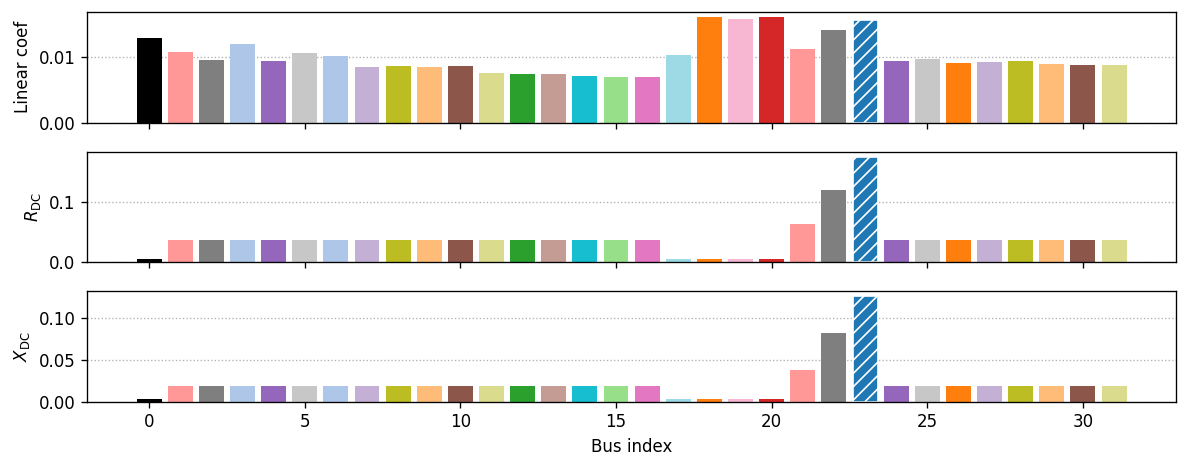

In [ ]:
dc_bus = dc_buses[1]

R_dc_self = R[dc_bus, dc_bus]
R_dc_row = R[dc_bus, :]
X_dc_row = X[dc_bus, :]

fig, axes = plt.subplots(3, 1, figsize=(10, 4), dpi=120, sharex=True)

for ax, data, ylabel in [
    (axes[0], np.asarray(linear_coff).reshape(-1), "Linear coef"),
    (axes[1], R_dc_row, r"$R_{\mathrm{DC}}$"),
    (axes[2], X_dc_row, r"$X_{\mathrm{DC}}$"),
]:
    bars = ax.bar(bus_idx, data, color=bus_colors)

    # Make the highlighted bar obvious: thick white edge + hatch (robust to dark colors)
    bars[dc_bus].set_edgecolor("white")
    bars[dc_bus].set_hatch("///")

    ax.set_axisbelow(True)  # keep grid behind bars
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8)

axes[2].set_xlabel("Bus index")
plt.tight_layout()
plt.show()


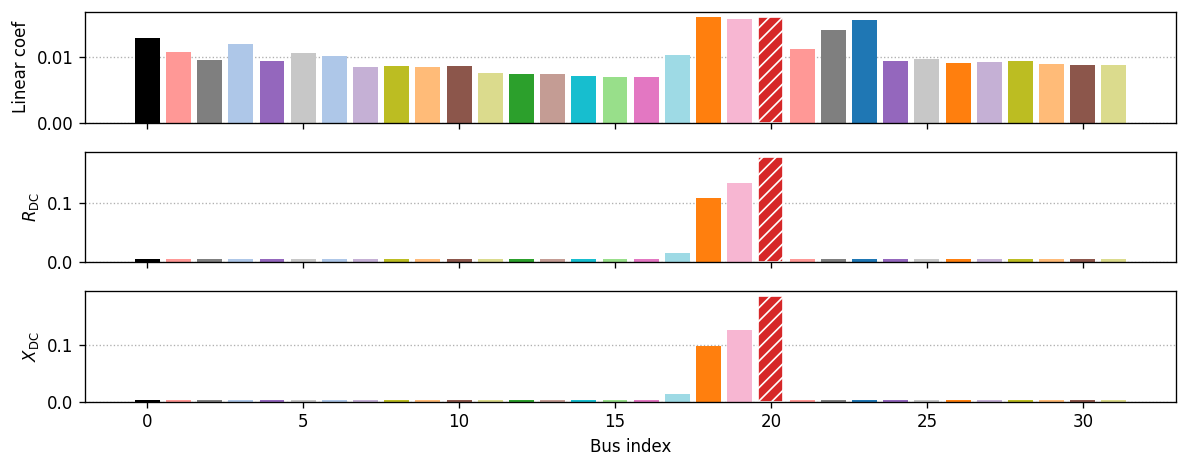

In [ ]:
dc_bus = dc_buses[0]

R_dc_self = R[dc_bus, dc_bus]
R_dc_row = R[dc_bus, :]
X_dc_row = X[dc_bus, :]

fig, axes = plt.subplots(3, 1, figsize=(10, 4), dpi=120, sharex=True)

for ax, data, ylabel in [
    (axes[0], np.asarray(linear_coff).reshape(-1), "Linear coef"),
    (axes[1], R_dc_row, r"$R_{\mathrm{DC}}$"),
    (axes[2], X_dc_row, r"$X_{\mathrm{DC}}$"),
]:
    bars = ax.bar(bus_idx, data, color=bus_colors)

    # Make the highlighted bar obvious: thick white edge + hatch (robust to dark colors)
    bars[dc_bus].set_edgecolor("white")
    bars[dc_bus].set_hatch("///")

    ax.set_axisbelow(True)  # keep grid behind bars
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8)

axes[2].set_xlabel("Bus index")
plt.tight_layout()
plt.show()


## action

In [ ]:
def action_linear(V, K, V_ref, deadband=0.0, u_max=0.01, **kwargs):
    e = V - V_ref

    # Deadband: ignore small deviations
    g = np.sign(e) * np.maximum(np.abs(e) - deadband, 0.0)

    u = -K * g

    # Saturation: enforce actuator limits
    if u_max is not None:
        u = np.clip(u, -u_max, u_max)

    return u


def action_fractional(V, K, V_ref, alpha=0.5, eps=1e-6, **kwargs):
    # u = -K * sign(e) * |e|^alpha  (smoothed near 0)
    e = V - V_ref
    return -K * e / (np.abs(e) + eps) * (np.abs(e) ** alpha)

ACTION_REGISTRY = {
    "linear": action_linear,
    "fractional": action_fractional,
}

## plot

In [ ]:
def set_adaptive_ylim(ax, data, ymin, ymax):
    """
    Set y-limits with a minimum range [ymin, ymax],
    but expand automatically if data exceeds it.
    """
    data_min = np.min(data)
    data_max = np.max(data)

    lower = min(ymin, data_min)
    upper = max(ymax, data_max)

    ax.set_ylim(lower, upper)

In [ ]:
def plot_dQ_and_V(
    record_dQ,
    record_V,
    record_Vref=None,
    dt=0.1,
    vmin=-0.05,
    vmax=0.05,
    dc_buses=dc_buses,
    plot_buses=None,
    show_legend=False,
    legend_ncol=4,
    save_path=None,
):
    """
    Plot ΔQ, voltage deviation, and optional reference voltage.
    Requires globals: dc_buses, bus_colors
    """
    record_dQ = np.asarray(record_dQ, dtype=np.float32)
    record_V = np.asarray(record_V, dtype=np.float32)
    if record_Vref is not None:
        record_Vref = np.asarray(record_Vref, dtype=np.float32)

    Tq, n = record_dQ.shape
    Tv, nv = record_V.shape
    assert nv == n
    if record_Vref is not None:
        Tr, nr = record_Vref.shape
        assert nr == n

    if plot_buses is None:
        plot_buses = list(range(n))
    else:
        plot_buses = list(plot_buses)
        assert all(0 <= i < n for i in plot_buses), \
            "plot_buses contains invalid bus index"

    t_q = dt * np.arange(1, Tq + 1)
    t_v = dt * np.arange(Tv)

    fig, axes = plt.subplots(
        1,
        3 if record_Vref is not None else 2,
        figsize=(18, 5.5),
        dpi=120,
    )
    axes = np.atleast_1d(axes)

    TITLE_FS, LABEL_FS, TICK_FS = 29, 27, 25
    LEGEND_FS = 19

    dQ_ylim = (-0.011, 0.011)
    dQ_yticks = [-0.01, -0.005, 0.0, 0.005, 0.01]

    V_ylim = (-0.1, 0.1)
    V_yticks = [-0.1, -0.05, 0.0, 0.05, 0.1]

    def plus_one_formatter(x, pos):
        return f"{x + 1:.2f}"

    def style_axis(ax):
        ax.tick_params(labelsize=TICK_FS, direction="in")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    def line_style(i):
        if i in dc_buses:
            return dict(lw=1.8, alpha=1.0, zorder=3)
        return dict(dashes=(20, 10), lw=0.8, alpha=1.0, zorder=1)

    def finish_axis(ax, ylabel, ylim, yticks):
        ax.set_ylabel(ylabel, fontsize=TITLE_FS)
        ax.set_xlabel("Time (s)", fontsize=LABEL_FS)
        ax.set_ylim(*ylim)
        ax.set_yticks(yticks)
        style_axis(ax)

    def draw_bus_curves(ax, t, data, add_labels=False):
        # Draw non-DC buses first.
        non_dc = [i for i in plot_buses if i not in dc_buses]
        dc = [i for i in plot_buses if i in dc_buses]

        for i in non_dc:
            ax.plot(
                t,
                data[:, i],
                color=bus_colors[i],
                label=f"Bus {i+2}" if add_labels else None,
                **line_style(i),
            )

        # Draw DC buses on top.
        for i in dc:
            ax.plot(
                t,
                data[:, i],
                color=bus_colors[i],
                label=f"Bus {i+2}" if add_labels else None,
                **line_style(i),
            )

    axQ = axes[0]
    draw_bus_curves(axQ, t_q, record_dQ, add_labels=False)
    finish_axis(axQ, r"$\Delta q$ (p.u.)", dQ_ylim, dQ_yticks)

    axV = axes[1]
    axV.axhspan(vmin, vmax, color="0.85", alpha=0.2, zorder=0)
    axV.axhline(vmax, color="0.6", ls="--", lw=1.2, zorder=1)
    axV.axhline(vmin, color="0.6", ls="--", lw=1.2, zorder=1)
    draw_bus_curves(axV, t_v, record_V, add_labels=show_legend)
    finish_axis(axV, r"$v$ (p.u.)", V_ylim, V_yticks)

    # Show voltage ticks as 1 + deviation.
    axV.yaxis.set_major_formatter(FuncFormatter(plus_one_formatter))

    if show_legend:
        handles, labels = axV.get_legend_handles_labels()

        # sort by bus index extracted from labels like "Bus 17"
        order = np.argsort([int(lbl.split()[-1]) for lbl in labels])
        handles = [handles[i] for i in order]
        labels = [labels[i] for i in order]

        leg = axV.legend(
            handles,
            labels,
            fontsize=LEGEND_FS,
            ncol=legend_ncol,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.04),
            frameon=True,
            fancybox=False,
            framealpha=0.9,
            handlelength=1.5,
            handletextpad=0.5,
            columnspacing=1.2,
            borderpad=0.3,
            labelspacing=0.3,
        )

    if record_Vref is not None:
        axR = axes[2]
        axR.axhspan(vmin, vmax, color="0.85", alpha=0.2, zorder=0)
        axR.axhline(vmax, color="0.6", ls="--", lw=1.2, zorder=1)
        axR.axhline(vmin, color="0.6", ls="--", lw=1.2, zorder=1)
        draw_bus_curves(axR, t_q, record_Vref, add_labels=show_legend)
        finish_axis(axR, r"$V_{\mathrm{ref}}$ (p.u.)", V_ylim, V_yticks)

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")

    plt.show()

    if record_Vref is None:
        return record_dQ, record_V
    return record_dQ, record_V, record_Vref


In [ ]:
def plot_Q_from_dQ(dQ, dc_bus, bus_aux, dt):
    """
    Plot ΔQ(t) and the resulting Q(t) trajectory implied by Q(t)=Q0+sum_{τ<=t}ΔQ(τ).
    Uses existing globals: Q0, bus_colors.
    """
    dQ = np.asarray(dQ, dtype=np.float32)                 # (T, n)
    Q_init = np.asarray(env.Q0, dtype=np.float32).reshape(-1) # (n,)

    t_dQ = dt * np.arange(dQ.shape[0])               # (T,)
    Q_traj = np.vstack([Q_init, Q_init + np.cumsum(dQ, axis=0)]).astype(np.float32)  # (T+1, n)
    t_Q = dt * np.arange(Q_traj.shape[0])            # (T+1,)

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 4), dpi=100)

    # ΔQ(t)
    for i in range(dQ.shape[1]):
        ax0.plot(t_dQ, dQ[:, i], color=bus_colors[i], lw=0.8, alpha=0.8)
    for i in bus_aux:
        ax0.plot(t_dQ, dQ[:, i], color=bus_colors[i], lw=1.8, alpha=1.0, zorder=3)
    dc_line, = ax0.plot(t_dQ, dQ[:, dc_bus], color=bus_colors[dc_bus], lw=1.2, alpha=0.6, zorder=4)
    dc_line.set_dashes([10, 6])
    ax0.set(xlabel="time (s)", title=r"$\Delta Q$")

    # Q(t)
    for i in range(Q_traj.shape[1]):
        ax1.plot(t_Q, Q_traj[:, i], color=bus_colors[i], lw=1.0, ls=":", alpha=1.0)
    for i in bus_aux:
        ax1.plot(t_Q, Q_traj[:, i], color=bus_colors[i], lw=3.0, ls=":", zorder=3)
    ax1.plot(t_Q, Q_traj[:, dc_bus], color=bus_colors[dc_bus], lw=3.0, alpha=0.6, zorder=4)
    ax1.set(xlabel="time (s)", title=r"$Q$")

    plt.tight_layout()
    plt.show()

# power

## variables

In [ ]:
start = 10
amp = 0.10 * 0.95 / R_dc_self

## realistic utils

In [ ]:
def rescale_diff(x, amp, return_scale=False, eps=1e-12):
    # rescale x to [0, amp]
    x = np.asarray(x)
    xmin, xmax = x.min(), x.max()
    d = xmax - xmin

    if d < eps:
        diff = np.zeros(len(x) - 1, dtype=np.float32)
        scale = 0.0
        return (diff, scale) if return_scale else diff

    y = (x - xmin) / d * amp
    diff = np.diff(y).astype(np.float32)
    scale = amp / d

    # first difference y[i+1] - y[i] (drops the first sample)
    return (diff, scale) if return_scale else diff


def make_dP_last_from_data(dP):
    """
    Build dP_last(t) from raw power data:
    rescale to [0, amp], then take first difference.
    """
    def dP_last(t):
        # return 0 after data ends (or you can clamp to last value)
        if 0 <= t < len(dP):
            return float(-dP[t])
        return 0.0

    T_total = len(dP)
    return dP_last, T_total


def plot_power_preprocessing(time_raw, pwr_raw, time_new, pwr_new, dP, dt_new):
    # Create three vertically stacked subplots
    fig, axes = plt.subplots(2, 1, figsize=(16, 4), sharex=True)

    # Plot raw power and interpolated signal
    axes[0].plot(time_raw, pwr_raw, lw=1.0, alpha=0.6, label="raw power")
    axes[0].plot(time_new, pwr_new, lw=1.8, label=f"interpolated (dt={dt_new}s)")
    axes[0].set_ylabel("Power")
    axes[0].grid(alpha=0.3)
    # axes[0].legend()

    # Plot first difference of the rescaled power
    dP_right = np.concatenate(([np.nan], dP))
    axes[1].plot(time_new, dP_right, lw=1.5)
    # axes[1].plot(time_new, dP_right, linestyle='None', marker='.', markersize=3, color='C3')
    axes[1].set_ylabel("dP")
    axes[1].grid(alpha=0.3)
    axes[1].set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()



# controller

###  `RingSeries`

In [ ]:
class RingSeries:
    """
    Fixed-length ring buffer for vector time series, with optional EMA.

    EMA definition (no special-cases needed):
        ema_t = (1 - beta) * ema_{t-1} + beta * x_t,  where 0 <= beta <= 1
        beta=None: no EMA is tracked
    """

    def __init__(self, length, shape, dtype=np.float32, beta=None, fill_value=np.nan):
        self.cap = int(length)
        if self.cap <= 0:
            raise ValueError(f"length must be positive, got {length}")

        self.shape = tuple(shape)
        self.dtype = dtype
        self.fill_value = fill_value

        if beta is None:
            self.beta = None
        else:
            b = float(beta)
            if not (0.0 <= b <= 1.0):
                raise ValueError(f"beta must be in [0,1], got {beta}")
            self.beta = b

        # Ring buffer and state.
        self.buf = np.full((self.cap, *self.shape),
                           np.array(self.fill_value, dtype=self.dtype),
                           dtype=self.dtype)
        self.ptr = 0          # next write position
        self.count = 0        # number of valid samples (<= cap)
        self.step = 0         # total updates seen (monotonic)

        # EMA state (initialized on first update).
        self.ema = None

    def reset(self):
        """Clear history and EMA."""
        self.buf[...] = np.array(self.fill_value, dtype=self.dtype)
        self.ptr = 0
        self.count = 0
        self.step = 0
        self.ema = None

    def push(self, x):
        x_arr = np.asarray(x, dtype=self.dtype).reshape(self.shape)

        # Write into ring buffer.
        self.buf[self.ptr, ...] = x_arr
        self.ptr = (self.ptr + 1) % self.cap
        self.count = min(self.count + 1, self.cap)
        self.step += 1

        # EMA update.
        if self.beta is not None:
            if self.ema is None:
                self.ema = x_arr.copy()
            else:
                b = self.beta
                self.ema[...] = (1.0 - b) * self.ema + b * x_arr

        return x_arr

    def get_last(self, k=1, oldest_first=True, require_full=False):
        if require_full and (self.count < self.cap):
            raise ValueError(f"buffer not full: count={self.count}, cap={self.cap}")

        if self.count == 0:
            return np.empty((0, *self.shape), dtype=self.dtype)

        k = int(k)
        if k <= 0:
            return np.empty((0, *self.shape), dtype=self.dtype)
        k = min(k, self.count)

        end = self.ptr
        start = (end - k) % self.cap

        if start < end:
            out = self.buf[start:end, ...].copy()
        else:
            out = np.concatenate((self.buf[start:, ...], self.buf[:end, ...]), axis=0).copy()

        if not oldest_first:
            out = out[::-1].copy()
        return out

    @property
    def full(self):
        """True if the ring buffer has accumulated cap samples."""
        return self.count == self.cap

### `BaseAdaController`

In [ ]:
class BaseAdaController:
    """Shared state, ring histories, offset update, cooldown, and action."""

    def __init__(
        self, n, K,
        *,
        # action
        action_type="linear", action_kwargs=None,
        # numerics
        eps=1e-8,
        # offset window (0 disables)
        bias_len=0, bias_per=None, bias_skip=0, bias_frac=0.3,
        # V history (0 disables). Must be >= off_len when offset enabled.
        v_hist_len=5000,
        # dV history (0 disables)
        dv_hist_len=0, dv_beta=None,
        # cooldown (0 disables)
        cooldown_steps=0,
    ):
        self.n = int(n)
        self.K = K
        self.eps = float(eps)
        self.dtype = np.float32

        # action
        self.action_kwargs = action_kwargs or {}
        if action_type not in ACTION_REGISTRY:
            raise ValueError(f"Unknown action_type={action_type}. Choose from {list(ACTION_REGISTRY.keys())}")
        self.action_fn = ACTION_REGISTRY[action_type]

        # states
        self.V_prev = None
        self.V_bias  = np.zeros((self.n, 1), dtype=self.dtype)
        self.V_amp_half  = np.zeros((self.n, 1), dtype=self.dtype)
        self.V_sign = np.zeros((self.n, 1), dtype=np.int8)   # -1/0/+1
        self.V_ref  = np.zeros((self.n, 1), dtype=self.dtype)

        # ---------------- offset config ----------------
        self.bias_len  = int(bias_len)
        self.bias_skip = int(bias_skip)
        self.bias_frac = float(bias_frac)

        if self.bias_len < 0:
            raise ValueError("off_len must be >= 0")
        if self.bias_skip < 0:
            raise ValueError("off_skip must be >= 0")

        # Period: decoupled from window length.
        # None means "use off_len" when enabled (backward compatible).
        if bias_per is None:
            bias_per = self.bias_len if self.bias_len > 0 else 0
        self.off_per = int(bias_per)

        if self.off_per < 0:
            raise ValueError("off_period must be >= 0")
        if self.bias_len > 0 and self.off_per <= 0:
            raise ValueError("off_period must be > 0 when offset is enabled (off_len > 0)")

        # ---------------- V history (decoupled) ----------------
        if v_hist_len is None:
            # Backward compatible default: keep exactly off_len samples if offset is enabled.
            v_hist_len = self.bias_len if self.bias_len > 0 else 0
        self.v_hist_len = int(v_hist_len)

        if self.v_hist_len < 0:
            raise ValueError("v_hist_len must be >= 0")

        if self.bias_len > 0:
            if not (0 <= self.bias_skip < self.bias_len):
                raise ValueError("off_skip must be in [0, off_len)")
            if not (0.0 <= self.bias_frac <= 1.0):
                raise ValueError("off_frac must be in [0, 1]")
            if self.v_hist_len <= 0:
                raise ValueError("v_hist_len must be > 0 when offset is enabled (off_len > 0)")
            if self.v_hist_len < self.bias_len:
                raise ValueError(f"v_hist_len ({self.v_hist_len}) must be >= off_len ({self.bias_len})")

            self.V_hist = RingSeries(self.v_hist_len, shape=(self.n,), dtype=self.dtype, beta=None)
        else:
            # Offset disabled; V_hist is not needed.
            self.V_hist = None

        # ---------------- dV history (+ optional EMA) ----------------
        self.dv_hist_len = int(dv_hist_len)
        if self.dv_hist_len < 0:
            raise ValueError("dv_hist_len must be >= 0")

        if self.dv_hist_len > 0:
            if dv_beta is not None:
                dv_beta = float(dv_beta)
                if not (0.0 < dv_beta <= 1.0):
                    raise ValueError("dv_beta must be in (0, 1] or None")
            self.dV_hist = RingSeries(self.dv_hist_len, shape=(self.n, 1), dtype=self.dtype, beta=dv_beta)
        else:
            self.dV_hist = None

        # ---------------- cooldown (steps only) ----------------
        self.cooldown_steps = int(cooldown_steps)
        if self.cooldown_steps < 0:
            raise ValueError("cooldown_steps must be >= 0")
        self.cooldown = np.zeros((self.n, 1), dtype=np.int32) if self.cooldown_steps > 0 else None

    # ------------------------------- basics -------------------------------

    def reset(self):
        self.V_prev = None
        self.V_bias[...] = 0
        self.V_amp_half[...] = 0
        self.V_sign[...] = 0
        self.V_ref[...] = 0
        if self.cooldown is not None:
            self.cooldown[...] = 0
        if self.V_hist is not None:
            self.V_hist.reset()
        if self.dV_hist is not None:
            self.dV_hist.reset()

    def _col(self, x):
        x = np.asarray(x, dtype=self.dtype).reshape(-1, 1)
        if x.shape[0] != self.n:
            raise ValueError(f"dimension mismatch: got {x.shape[0]}, expected {self.n}")
        return x

    def safe_range(self):
        return np.maximum(2.0 * self.V_amp_half, self.eps)

    # ------------------------------ histories -----------------------------

    def update_histories(self, V):
        """Return (dV_raw, dV_eff). dV_eff is EMA if enabled, else dV_raw."""
        dV = np.zeros_like(V) if self.V_prev is None else (V - self.V_prev)

        if self.V_hist is not None:
            self.V_hist.push(V.reshape(-1))

        if self.dV_hist is not None:
            self.dV_hist.push(dV)
            if self.dV_hist.beta is not None:
                return dV, self.dV_hist.ema

        return dV, dV

    # ------------------------------- offset -------------------------------

    def maybe_update_offset(self):
        """
        Update V_off periodically using the most recent off_len samples.

        - Window length: off_len (how many past samples are used)
        - Update period: off_period (how often we update)
        - Requires V_hist.count >= off_len (does NOT require ring full)
        """
        if self.V_hist is None or self.bias_len <= 0:
            return

        if (self.V_hist.count < self.bias_len) or (self.off_per <= 0):
            return

        if self.V_hist.step % self.off_per != 0:
            return

        W = self.V_hist.get_last(self.bias_len, oldest_first=True)  # (off_len, n)
        if self.bias_skip > 0:
            W = W[self.bias_skip:, :]
        center = 0.5 * (W.max(axis=0) + W.min(axis=0))             # (n,)
        self.V_bias[:, 0] -= (self.bias_frac * center).astype(self.dtype, copy=False)

    # ------------------------------ cooldown ------------------------------

    def cooldown_free(self, mask=None):
        """Return a boolean mask of buses allowed to switch."""
        if self.cooldown is None:
            if mask is None:
                return np.ones((self.n, 1), dtype=bool)
            out = np.zeros((self.n, 1), dtype=bool)
            out[mask] = True
            return out

        if mask is None:
            return self.cooldown <= 0

        out = np.zeros((self.n, 1), dtype=bool)
        out[mask] = (self.cooldown[mask] <= 0)
        return out

    def cooldown_tick(self, mask=None):
        if self.cooldown is None:
            return
        if mask is None:
            m = self.cooldown > 0
            self.cooldown[m] -= 1
        else:
            m = (self.cooldown > 0) & mask
            self.cooldown[m] -= 1

    def cooldown_clear(self, mask):
        if self.cooldown is None:
            return
        self.cooldown[mask] = 0

    def cooldown_start(self, mask):
        if self.cooldown is None:
            return
        self.cooldown[mask] = self.cooldown_steps

    # ------------------------------- v_ref --------------------------------

    def set_vref(self, mask=None):
        """V_ref = V_off + V_sign * V_amp_half."""
        if mask is None:
            self.V_ref[...] = self.V_bias + self.V_sign.astype(self.dtype, copy=False) * self.V_amp_half
        else:
            self.V_ref[mask] = self.V_bias[mask] + self.V_sign[mask].astype(self.dtype, copy=False) * self.V_amp_half[mask]

    # ------------------------------- metric -------------------------------

    def metric_dc(self, m, dc_bus):
        """Pick DC metric value from scalar or per-bus metric."""
        return m if np.ndim(m) == 0 else m[dc_bus]

    def metric_vec(self, m):
        """Return a length-n vector metric (broadcast scalar if needed)."""
        if np.ndim(m) == 0:
            return np.full(self.n, m, dtype=self.dtype)
        return m

    # ------------------------------- action -------------------------------

    def act(self, V):
        return self.action_fn(V, self.K, self.V_ref, **self.action_kwargs).astype(self.dtype, copy=False)

### MaxDV + VBias

In [ ]:
class AdaRefVBiasAmpMaxDV(BaseAdaController):
    """
    Per-bus sign selection (unchanged) + per-bus amp update from a rolling max-|dV| window.

    Sign rule (per bus):
        (example) V > V_bias => +1 else -1
      with optional cooldown gating.

    Amp rule (per bus):
        V_amp_half <- amp_gain * max_{t in last amp_win_len} |dV_t|
      updated periodically (default: every step).
    """

    def __init__(
        self,
        n, K,
        *,
        action_type="linear", action_kwargs=None,
        bias_len=0, bias_per=None, bias_skip=0, bias_frac=0.3,
        dv_hist_len=5000, dv_beta=None,
        cooldown_steps=0,
        eps=1e-8,
        # ---------------- amp (rolling max-|dV|) ----------------
        amp_gain=0.5, amp_win_len=30, amp_per=1, amp_min=None,
    ):
        super().__init__(
            n, K,
            action_type=action_type, action_kwargs=action_kwargs,
            eps=eps,
            bias_len=bias_len, bias_per=bias_per, bias_skip=bias_skip, bias_frac=bias_frac,
            dv_hist_len=dv_hist_len, dv_beta=dv_beta,
            cooldown_steps=cooldown_steps,
        )

        # ---------------- amp config ----------------
        self.amp_gain = float(amp_gain)
        if self.amp_gain < 0:
            raise ValueError("amp_gain must be >= 0")

        self.amp_win_len = int(amp_win_len)
        if self.amp_win_len <= 0:
            raise ValueError("amp_win_len must be positive")

        self.amp_per = int(amp_per)
        if self.amp_per <= 0:
            raise ValueError("amp_per must be positive (>= 1)")

        if self.dV_hist is None:
            raise ValueError("dv_hist_len must be > 0 to enable amp update")
        if self.dv_hist_len < self.amp_win_len:
            raise ValueError(f"dv_hist_len ({self.dv_hist_len}) must be >= amp_win_len ({self.amp_win_len})")

        # optional per-bus floor for robustness (e.g., avoid vanishing amp in steady state)
        if amp_min is None:
            self.amp_min = None
        else:
            mn = np.asarray(amp_min, dtype=self.dtype).reshape(-1)
            if mn.size == 1:
                mn = np.full(self.n, mn.item(), dtype=self.dtype)
            if mn.size != self.n:
                raise ValueError(f"amp_min must be scalar or length n={self.n}")
            if np.any(mn < 0):
                raise ValueError("amp_min must be >= 0")
            self.amp_min = mn.reshape(-1, 1)

        # ---------------- amp logs/state ----------------
        self.amp_maxabs_dv = np.full((self.n, 1), np.nan, dtype=self.dtype)

    def reset(self):
        super().reset()
        self.amp_maxabs_dv[...] = np.nan

    # --------------------------- amp update ---------------------------

    def _dv_window_maxabs(self):
        """Max of |dV| over last amp_win_len samples, per bus."""
        # if self.dV_hist.count < self.amp_win_len:
        #     return None, False

        W = self.dV_hist.get_last(self.amp_win_len, oldest_first=True)  # (win, n, 1)
        if W.size == 0:
            return None, False

        # (win, n)
        W = W[:, :, 0]
        if not np.isfinite(W).all():
            return None, False

        m = np.max(np.abs(W), axis=0).astype(self.dtype, copy=False).reshape(-1, 1)
        return m, True

    def _maybe_update_amp_maxdv(self):
        """
        Periodically update V_amp_half from rolling max-|dV|.
        Returns a boolean mask of buses where amp was updated.
        """
        updated = np.zeros((self.n, 1), dtype=bool)

        # "fastest" default: amp_per=1 => update every step
        if (self.dV_hist.step % self.amp_per) != 0:
            return updated

        m, ok = self._dv_window_maxabs()
        if not ok:
            return updated

        self.amp_maxabs_dv[...] = m

        # compute new amp
        new_amp = (self.amp_gain * m).astype(self.dtype, copy=False)
        if self.amp_min is not None:
            new_amp = np.maximum(new_amp, self.amp_min)

        # update all buses (you can easily change to conditional update if needed)
        self.V_amp_half[...] = new_amp
        updated[...] = True
        return updated

    # ---------------------------------- step ----------------------------------

    def step(self, V):
        V = self._col(V)
        if self.V_prev is None:
            self.V_prev = V.copy()
            self.set_vref()  # starts at V_bias (sign = 0)
            return np.zeros_like(V)

        # (0) histories + offset
        self.update_histories(V)
        self.maybe_update_offset()

        # (1) amplitude update via rolling max-|dV|
        amp_updated = self._maybe_update_amp_maxdv()

        # (2) cooldown tick + clear on amp update (kept consistent with your pattern)
        self.cooldown_tick()
        # self.cooldown_clear(amp_updated)
        free = self.cooldown_free()

        # (3) metric -> desired sign (example rule retained)
        desired = np.where(V > self.V_bias, +1, -1).astype(np.int8).reshape(-1, 1)
        did_switch = free & (desired != self.V_sign)
        if np.any(did_switch):
            self.V_sign[did_switch] = desired[did_switch]
        self.cooldown_start(did_switch)

        # (4) rebuild V_ref and act
        self.set_vref()
        out = self.act(V)
        self.V_prev = V.copy()
        return out

# realistic data

## torch_ckpt_end

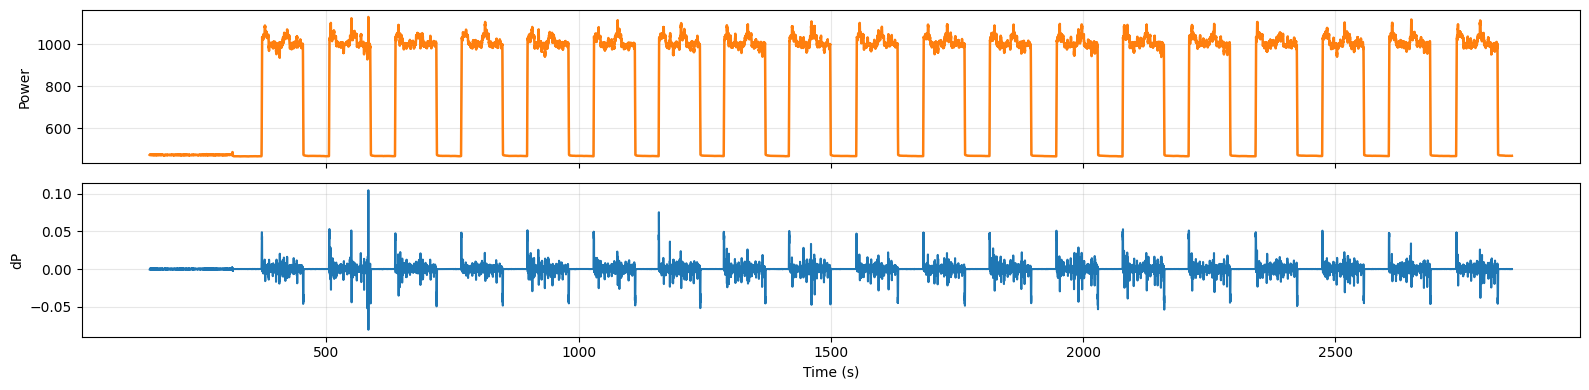

In [ ]:
amp = 0.10 * 0.95 / R_dc_self

# data loading
data_dir = osp.join("..", "data", "traces_raw")
filename = "L2-70B-chat_4xH200_HF_qlora_tp_async_b16x2_seq2048_r64_ckpt1.csv"
df = pd.read_csv(osp.join(data_dir, filename))

# select a time window
slice_range = slice(1500, 28500)
t_raw  = df["t"][slice_range].to_numpy(np.float64)
pwr_raw = df["pwr"][slice_range].to_numpy(np.float32)

# system grid
# t_sys = np.arange(t_raw[0], t_raw[-1] + 1e-9, dt_sys, dtype=np.float64)
# pwr_sys = np.interp(t_sys, t_raw, pwr_raw).astype(np.float32)
t_sys = t_raw
pwr_sys = pwr_raw

# pwr grid: subsampled from system grid
t_pwr = t_sys[::stride_pwr]
pwr_pwr = -pwr_sys[::stride_pwr]

# system disturbance
dP_sys, scale = rescale_diff(pwr_sys, amp, return_scale=True)
dP_last, T_sys = make_dP_last_from_data(dP_sys)
v_sens = scale * R_dc_row  # (n,)
SimulationLength = T_sys

# visualize (system grid)
plot_power_preprocessing(t_raw, pwr_raw, t_sys, pwr_sys, dP_sys, dt_sys)

### zero-ref

#### w/o deadband

[Seed set]: 42


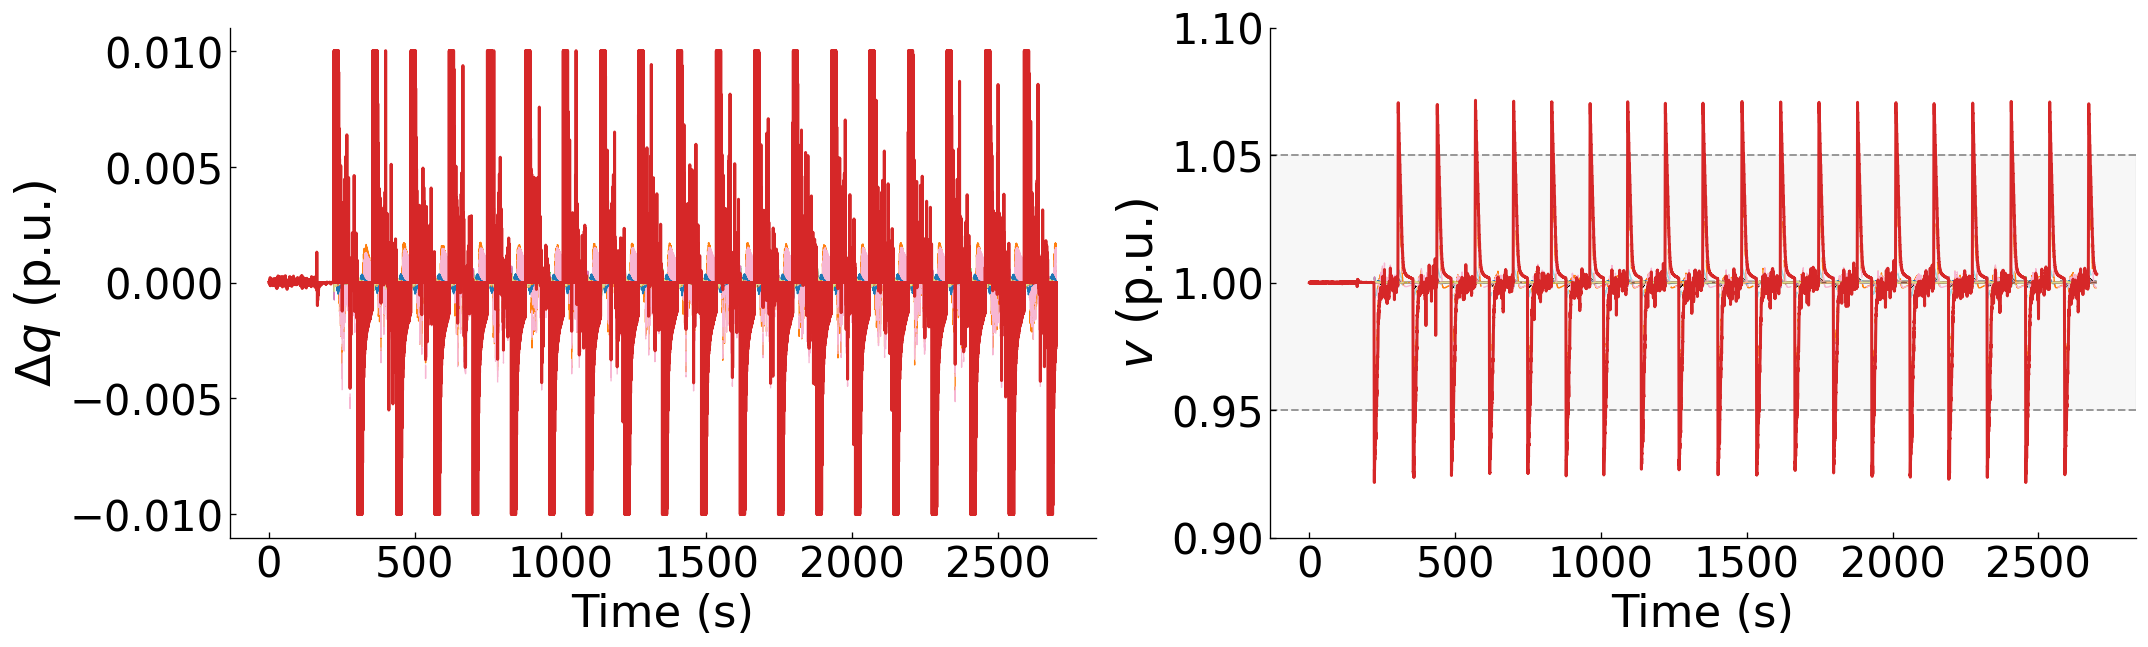

In [ ]:
# --- user-defined configuration ---
stride_ctrl = 10
# gain_scale = 15
gain_scale = 50
deadband = 0.0

# --- derived parameters and main simulation loop --
set_seed(SEED)
dt_ctrl = stride_ctrl * dt_sys
V = env.reset(P=P0_INIT, balance_Q=True)

# --- logging buffers ---
record_dQ = []
record_V = [V.squeeze().copy()]

for k_sys in range(SimulationLength):
    dP_t = np.zeros_like(P0)
    dP_t[dc_bus, 0] = dP_last(k_sys)

    dQ = np.zeros((num_buses, 1), dtype=np.float32)  # impulse control: only nonzero at ctrl steps
    if k_sys % stride_ctrl == 0:
        V_ref = np.zeros((num_buses, 1), dtype=np.float32)
        dQ = action_linear(V, linear_coff * gain_scale, V_ref, deadband=deadband).reshape(num_buses, 1).astype(np.float32)

    V = env.step(dQ, dP=dP_t)

    record_dQ.append(dQ.squeeze().copy())
    record_V.append(V.squeeze().copy())

# visualizatoin
record_dQ, record_V = plot_dQ_and_V(record_dQ, record_V, dt=env.dt, dc_buses=[dc_bus])

#### deadband=0.02

[Seed set]: 42


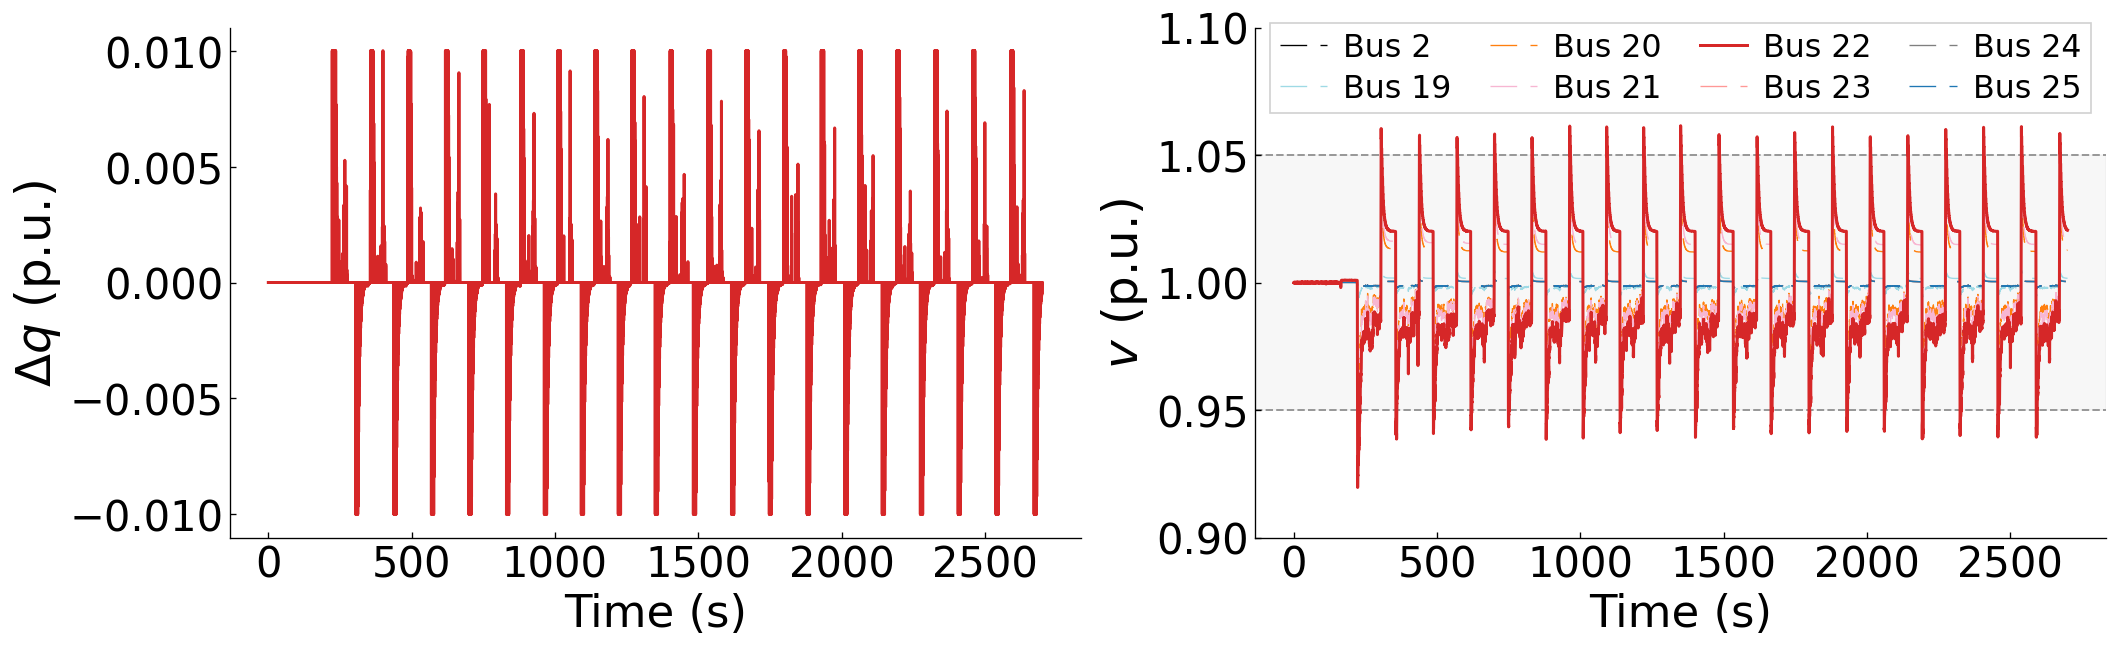

In [ ]:
# --- user-defined configuration ---
stride_ctrl = 10
# gain_scale = 15
gain_scale = 50
deadband = 0.02

# --- derived parameters and main simulation loop --
set_seed(SEED)
dt_ctrl = stride_ctrl * dt_sys
V = env.reset(P=P0_INIT, balance_Q=True)

# --- logging buffers ---
record_dQ = []
record_V = [V.squeeze().copy()]

for k_sys in range(SimulationLength):
    dP_t = np.zeros_like(P0)
    dP_t[dc_bus, 0] = dP_last(k_sys)

    dQ = np.zeros((num_buses, 1), dtype=np.float32)  # impulse control: only nonzero at ctrl steps
    if k_sys % stride_ctrl == 0:
        V_ref = np.zeros((num_buses, 1), dtype=np.float32)
        dQ = action_linear(V, linear_coff * gain_scale, V_ref, deadband=deadband).reshape(num_buses, 1).astype(np.float32)

    V = env.step(dQ, dP=dP_t)

    record_dQ.append(dQ.squeeze().copy())
    record_V.append(V.squeeze().copy())

# visualizatoin
record_dQ, record_V = plot_dQ_and_V(record_dQ, record_V, dt=env.dt, dc_buses=[dc_bus], plot_buses=plot_buses, show_legend=True)

In [ ]:
results = {}
results["zero_ref"] = {
    "dQ": record_dQ[:, dc_bus],
    "V": record_V[:, dc_bus],
}

### ada-ref

#### w/o deadband

[Seed set]: 42


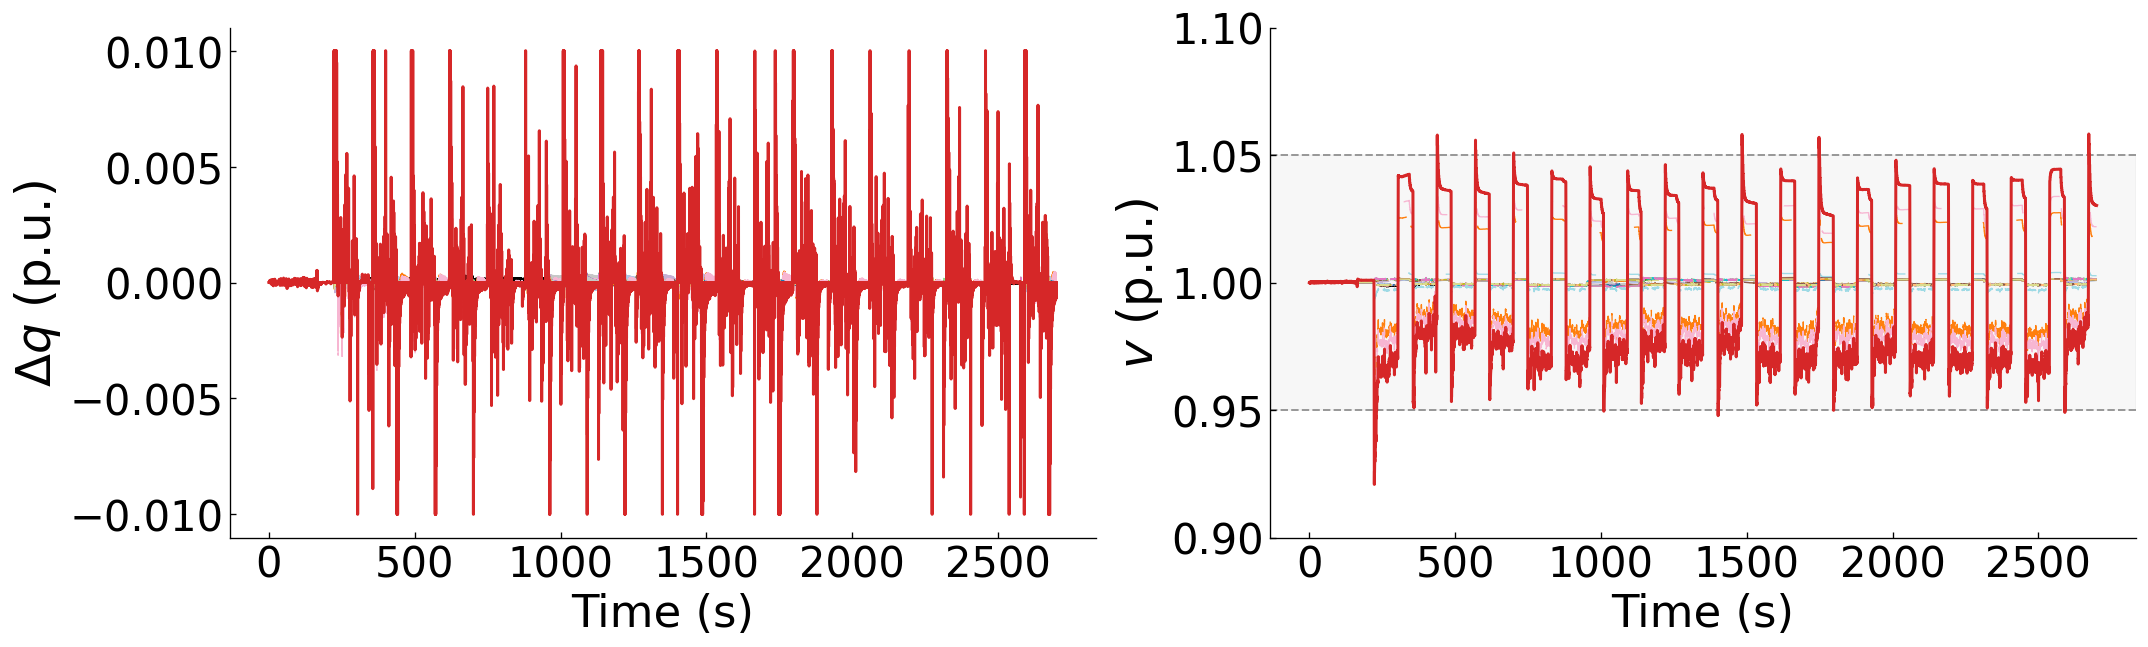

In [ ]:
# --- user-defined configuration ---
stride_ctrl = 10
gain_scale = 50
action_kwargs = {"deadband": 0.0}
bias_win_secs, bias_per_secs, bias_skip_secs, bias_frac = 120, 10, 0, 0.020
amp_win_secs = 120

# --- derived parameters and main simulation loop ---
set_seed(SEED)
dt_ctrl = stride_ctrl * dt_sys

bias_len  = max(0, int(round(bias_win_secs  / dt_ctrl)))
bias_per = int(round(bias_per_secs / dt_ctrl))
bias_skip = int(round(bias_skip_secs / dt_ctrl))

amp_win_len  = max(1, int(round(amp_win_secs / dt_ctrl)))
dv_hist_len = max(amp_win_len, 5000)   # make sure >= amp_win_len

V = env.reset(P=P0_INIT, balance_Q=True)
controller = AdaRefVBiasAmpMaxDV(
    n=num_buses,
    K=linear_coff * gain_scale, action_kwargs=action_kwargs,
    bias_len=bias_len, bias_per=bias_per, bias_skip=bias_skip, bias_frac=bias_frac,
    dv_hist_len=dv_hist_len, dv_beta=None,
    cooldown_steps=0,
    amp_gain=0.5, amp_win_len=amp_win_len, amp_per=1, amp_min=None,
)

# --- logging buffers ---
record_dQ = []
record_Vref = []
record_V = [V.squeeze().copy()]

for k_sys in range(SimulationLength):
    # Real power fluctuation at data center bus
    dP_t = np.zeros_like(P0)
    dP_t[dc_bus, 0] = dP_last(k_sys)

    # Reactive power control update only at control stride
    dQ = np.zeros((num_buses, 1), dtype=np.float32)
    if k_sys % stride_ctrl == 0:
        dQ = controller.step(V).reshape(num_buses, 1).astype(np.float32)

    # Propagate system dynamics
    V = env.step(dQ, dP=dP_t)

    # logging
    record_dQ.append(dQ.squeeze().copy())
    record_Vref.append(controller.V_ref.squeeze().copy())
    record_V.append(V.squeeze().copy())

# visualization
# record_dQ, record_V, record_Vref = plot_dQ_and_V(record_dQ, record_V, record_Vref, dt=env.dt)
record_dQ, record_V = plot_dQ_and_V(record_dQ, record_V, dt=env.dt, dc_buses=[dc_bus])

#### deadband=0.02

[Seed set]: 42


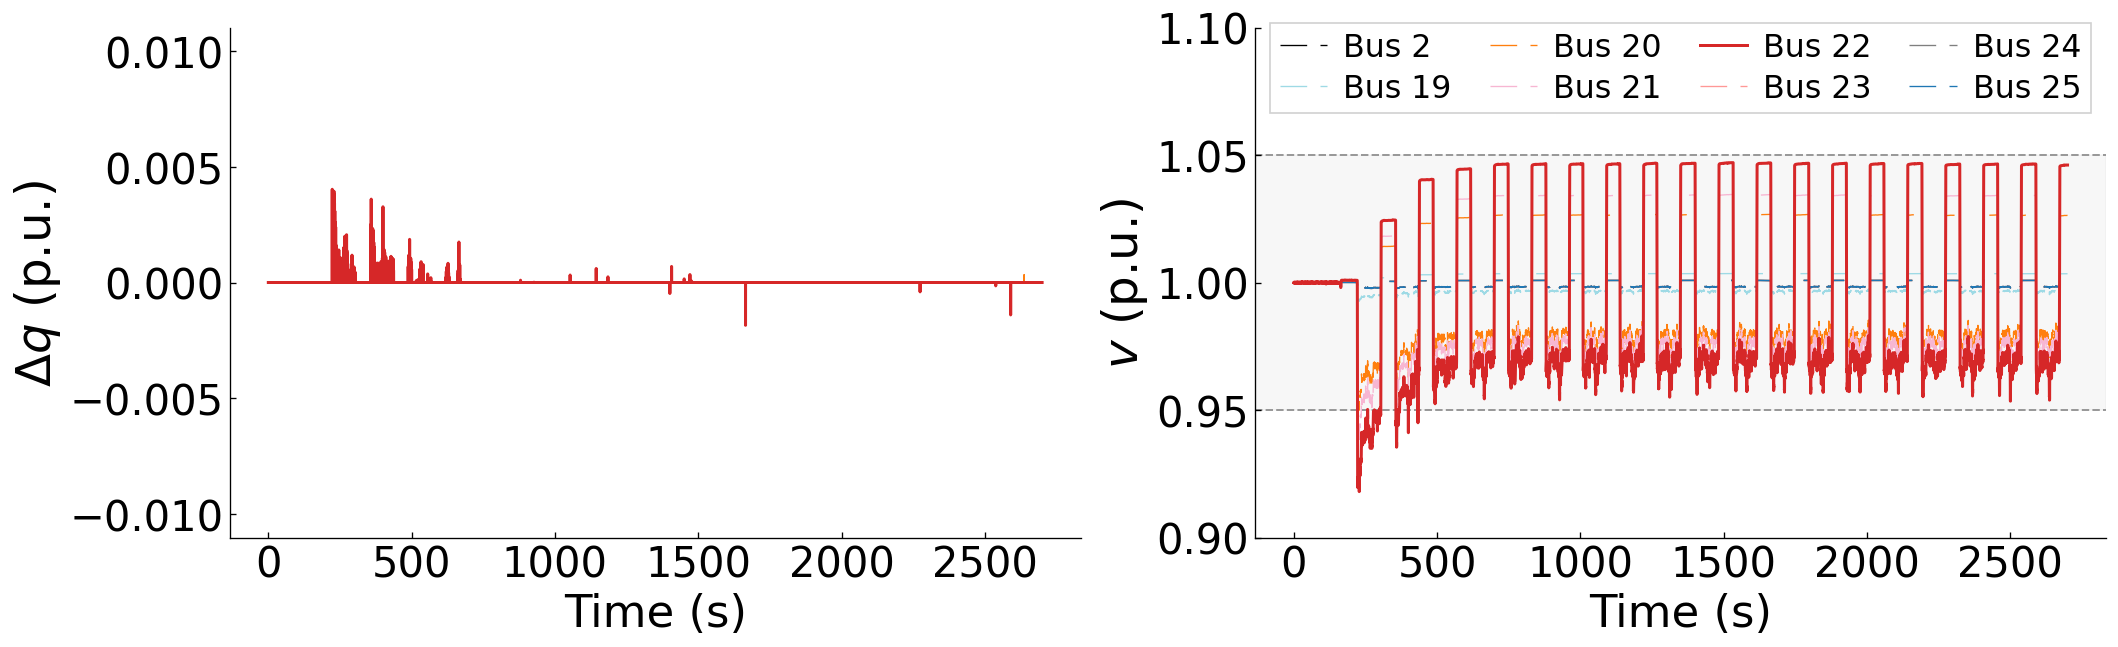

In [ ]:
# --- user-defined configuration ---
stride_ctrl = 10
# gain_scale = 50
gain_scale = 10
action_kwargs = {"deadband": 0.02}
bias_win_secs, bias_per_secs, bias_skip_secs, bias_frac = 120, 10, 0, 0.020
amp_win_secs = 120

# --- derived parameters and main simulation loop ---
set_seed(SEED)
dt_ctrl = stride_ctrl * dt_sys

bias_len  = max(0, int(round(bias_win_secs  / dt_ctrl)))
bias_per = int(round(bias_per_secs / dt_ctrl))
bias_skip = int(round(bias_skip_secs / dt_ctrl))

amp_win_len  = max(1, int(round(amp_win_secs / dt_ctrl)))
dv_hist_len = max(amp_win_len, 5000)   # make sure >= amp_win_len

V = env.reset(P=P0_INIT, balance_Q=True)
controller = AdaRefVBiasAmpMaxDV(
    n=num_buses,
    K=linear_coff * gain_scale, action_kwargs=action_kwargs,
    bias_len=bias_len, bias_per=bias_per, bias_skip=bias_skip, bias_frac=bias_frac,
    dv_hist_len=dv_hist_len, dv_beta=None,
    cooldown_steps=0,
    amp_gain=0.5, amp_win_len=amp_win_len, amp_per=1, amp_min=None,
)

# --- logging buffers ---
record_dQ = []
record_Vref = []
record_V = [V.squeeze().copy()]

for k_sys in range(SimulationLength):
    # Real power fluctuation at data center bus
    dP_t = np.zeros_like(P0)
    dP_t[dc_bus, 0] = dP_last(k_sys)

    # Reactive power control update only at control stride
    dQ = np.zeros((num_buses, 1), dtype=np.float32)
    if k_sys % stride_ctrl == 0:
        dQ = controller.step(V).reshape(num_buses, 1).astype(np.float32)

    # Propagate system dynamics
    V = env.step(dQ, dP=dP_t)

    # logging
    record_dQ.append(dQ.squeeze().copy())
    record_Vref.append(controller.V_ref.squeeze().copy())
    record_V.append(V.squeeze().copy())

# visualization
# record_dQ, record_V, record_Vref = plot_dQ_and_V(record_dQ, record_V, record_Vref, dt=env.dt)
record_dQ, record_V = plot_dQ_and_V(record_dQ, record_V, dt=env.dt, dc_buses=[dc_bus], plot_buses=plot_buses, show_legend=True)

In [ ]:
results["ada_ref"] = {
    "dQ": record_dQ[:, dc_bus],
    "V": record_V[:, dc_bus],
}

### comparison

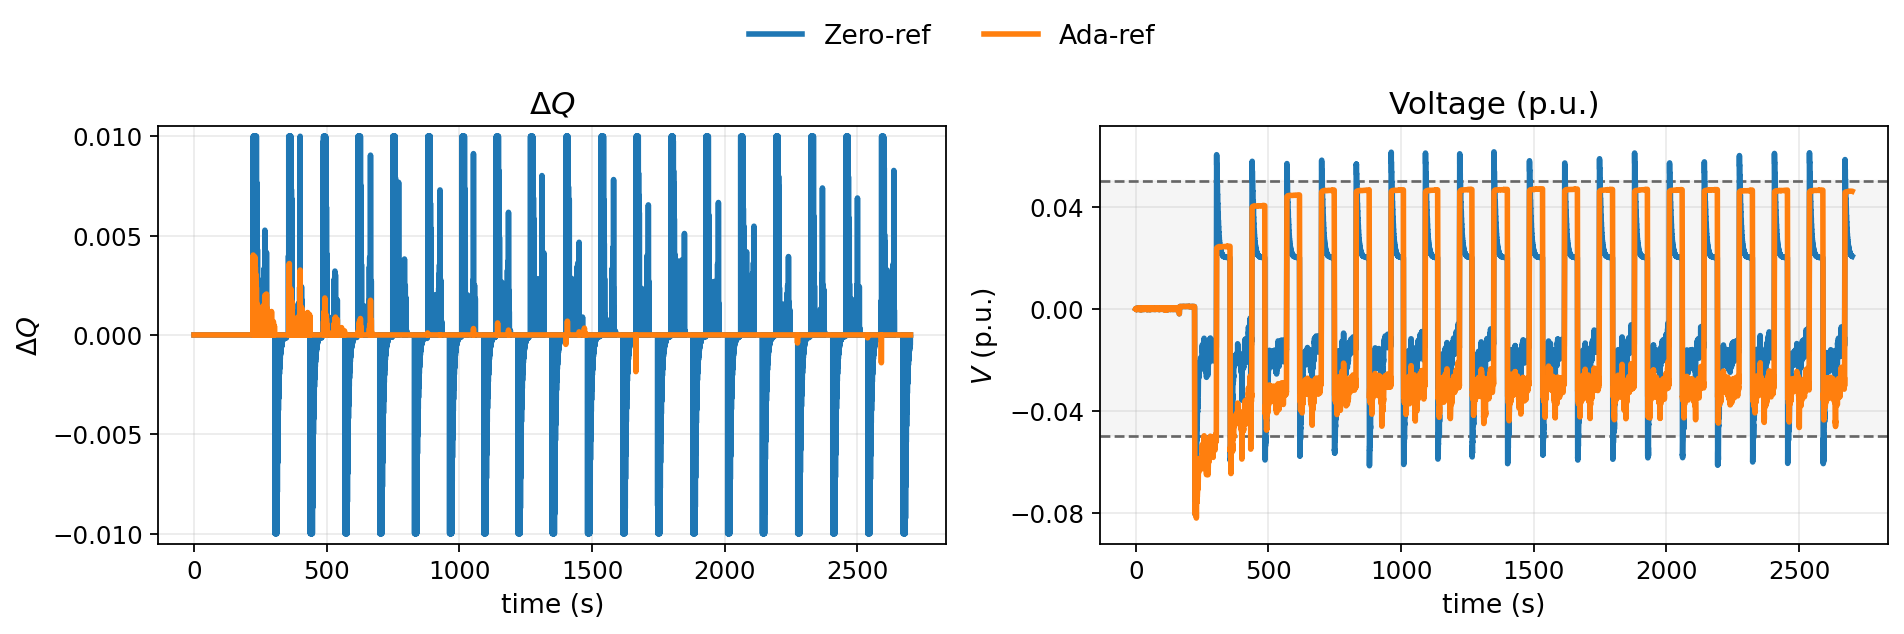

In [ ]:
def plot_dc_compare(results, dt=0.1, vmin=-0.05, vmax=0.05,
                    names=("zero_ref", "ada_ref"),
                    labels=("Zero-ref", "Ada-ref")):

    z, a = names
    dq0, v0 = np.asarray(results[z]["dQ"]), np.asarray(results[z]["V"])
    dq1, v1 = np.asarray(results[a]["dQ"]), np.asarray(results[a]["V"])

    t_q0, t_v0 = dt*np.arange(1, len(dq0)+1), dt*np.arange(len(v0))
    t_q1, t_v1 = dt*np.arange(1, len(dq1)+1), dt*np.arange(len(v1))

    c0, c1 = plt.get_cmap("tab10")(0), plt.get_cmap("tab10")(1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=160)

    # --- ΔQ ---
    ax[0].plot(t_q0, dq0, color=c0, lw=2.5, label=labels[0])
    ax[0].plot(t_q1, dq1, color=c1, lw=2.5, label=labels[1])
    ax[0].set_title(r"$\Delta Q$", fontsize=14)
    ax[0].set_xlabel("time (s)", fontsize=12)
    ax[0].set_ylabel(r"$\Delta Q$", fontsize=12)
    ax[0].grid(True, alpha=0.25)

    # Fewer ticks
    ax[0].xaxis.set_major_locator(MaxNLocator(6))
    ax[0].yaxis.set_major_locator(MaxNLocator(5))

    lim = max(np.max(np.abs(dq0)), np.max(np.abs(dq1)), 1e-6)
    ax[0].set_ylim(-1.05*lim, 1.05*lim)

    # --- V ---
    ax[1].axhspan(vmin, vmax, color="0.85", alpha=0.25, zorder=0)
    ax[1].axhline(vmax, color="0.4", ls="--", lw=1.2)
    ax[1].axhline(vmin, color="0.4", ls="--", lw=1.2)

    ax[1].plot(t_v0, v0, color=c0, lw=2.5)
    ax[1].plot(t_v1, v1, color=c1, lw=2.5)

    ax[1].set_title("Voltage (p.u.)", fontsize=14)
    ax[1].set_xlabel("time (s)", fontsize=12)
    ax[1].set_ylabel(r"$V$ (p.u.)", fontsize=12)
    ax[1].grid(True, alpha=0.25)

    ax[1].xaxis.set_major_locator(MaxNLocator(6))
    ax[1].yaxis.set_major_locator(MaxNLocator(5))

    ylo = min(v0.min(), v1.min(), vmin) - 0.01
    yhi = max(v0.max(), v1.max(), vmax) + 0.01
    ax[1].set_ylim(ylo, yhi)

    # Larger tick labels
    for axt in ax:
        axt.tick_params(labelsize=11)

    # Top legend
    handles, labs = ax[0].get_legend_handles_labels()
    fig.legend(handles, labs, loc="upper center", ncol=2,
               frameon=False, fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

plot_dc_compare(results, dt=0.1, vmin=-0.05, vmax=0.05)

## torch_ckpt_end regulated

### load data

#### unregulated data

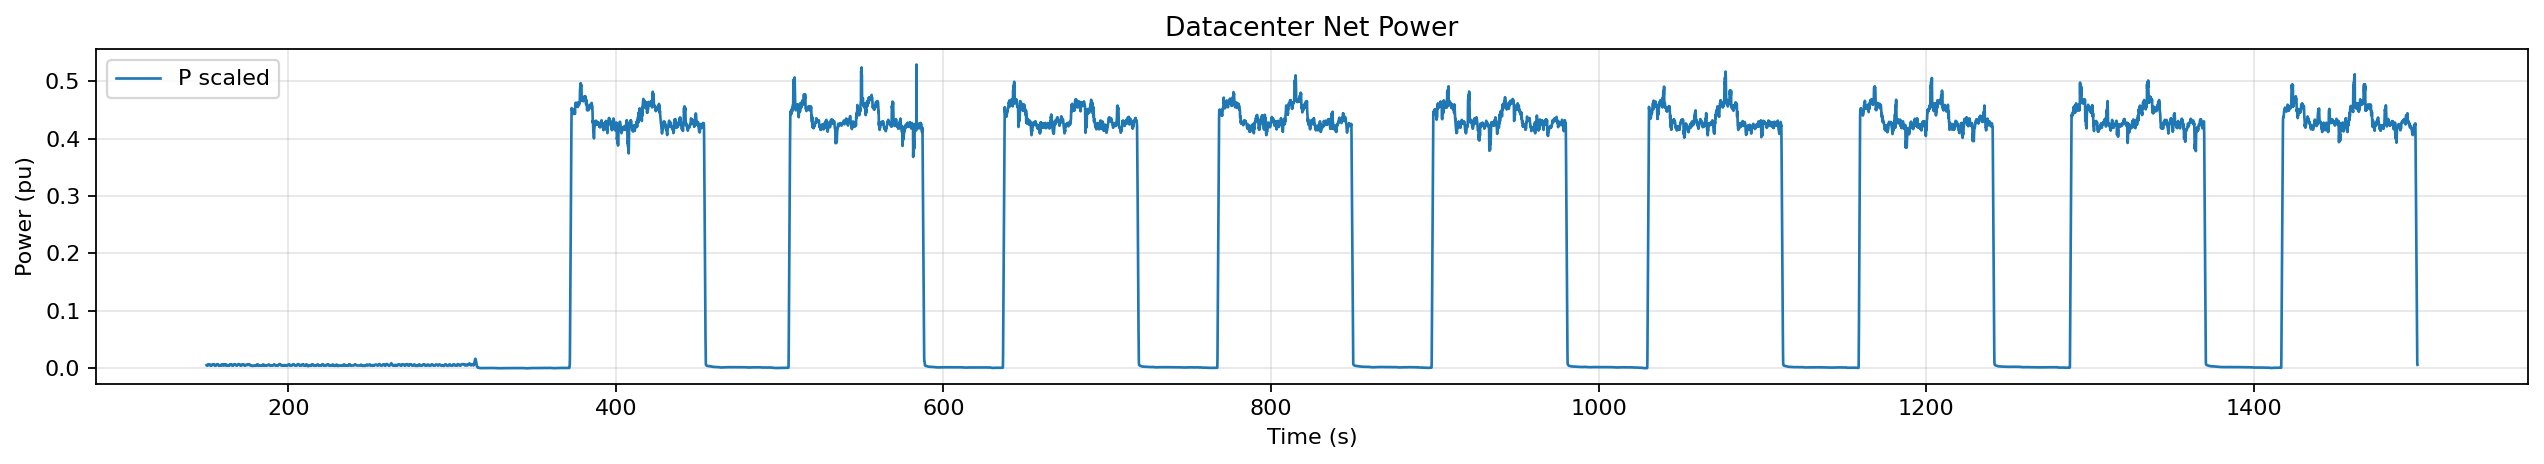

In [ ]:
amp = 0.10 * 0.95 / R_dc_self

# data loading
data_dir = osp.join("..", "data", "traces_raw")
filename = "L2-70B-chat_4xH200_HF_qlora_tp_async_b16x2_seq2048_r64_ckpt1.csv"
df = pd.read_csv(osp.join(data_dir, filename))

# select a time window
# slice_range = slice(1500, 15000)
slice_range = slice(1500, 15001)
t_raw  = df["t"][slice_range].to_numpy(np.float64)
pwr_raw = df["pwr"][slice_range].to_numpy(np.float32)

# system grid
# t_sys = np.arange(t_raw[0], t_raw[-1] + 1e-9, dt_sys, dtype=np.float64)
# pwr_sys = np.interp(t_sys, t_raw, pwr_raw).astype(np.float32)
t_sys = t_raw
pwr_sys = pwr_raw

# pwr grid: subsampled from system grid
t_pwr = t_sys[::stride_pwr]
pwr_pwr = -pwr_sys[::stride_pwr]

# system disturbance
dP_sys, scale = rescale_diff(pwr_sys, amp, return_scale=True)

# ============
# === plot ===
# ============
dP_sys, scale = rescale_diff(pwr_sys, amp, return_scale=True)

# recover the scaled P sequence from dP
xmin, xmax = np.min(pwr_sys), np.max(pwr_sys)
p0 = (pwr_sys[0] - xmin) / (xmax - xmin) * amp
pwr_sys_scale = np.concatenate([[p0], p0 + np.cumsum(dP_sys)])

# plot
plt.figure(figsize=(16, 3), dpi=160)
plt.plot(t_pwr, pwr_sys_scale, lw=1.2, label="P scaled")

plt.xlabel("Time (s)")
plt.ylabel("Power (pu)")
plt.title("Datacenter Net Power")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### regulated data

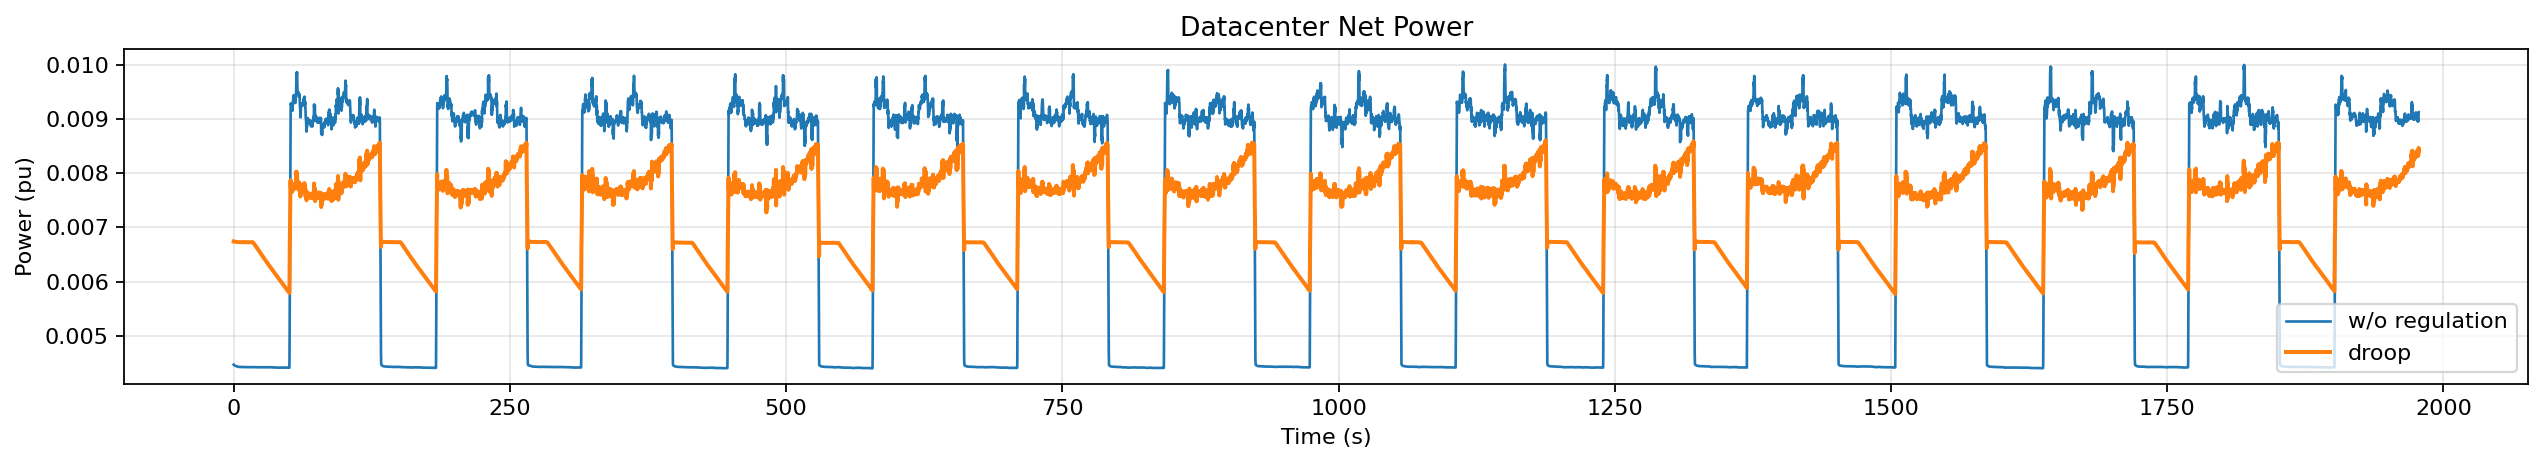

In [ ]:
save_path = osp.join("..", "data", "traces_regulated.pkl")
with open(save_path, "rb") as f:
    results = pickle.load(f)
slice_range = slice(None, 20300)
# slice_range = slice(None, 15500-1500)

ts = results["t"][slice_range]
P_base = results["unregulated"]["Pinj_dc"][slice_range]
P_net = results["regulated"]["Pinj_dc"][slice_range]

# plot
plt.figure(figsize=(16, 3), dpi=160)

plt.plot(ts, P_base, lw=1.2, label="w/o regulation")
plt.plot(ts, P_net,  lw=1.8, label="droop")

plt.xlabel("Time (s)")
plt.ylabel("Power (pu)")
plt.title("Datacenter Net Power")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

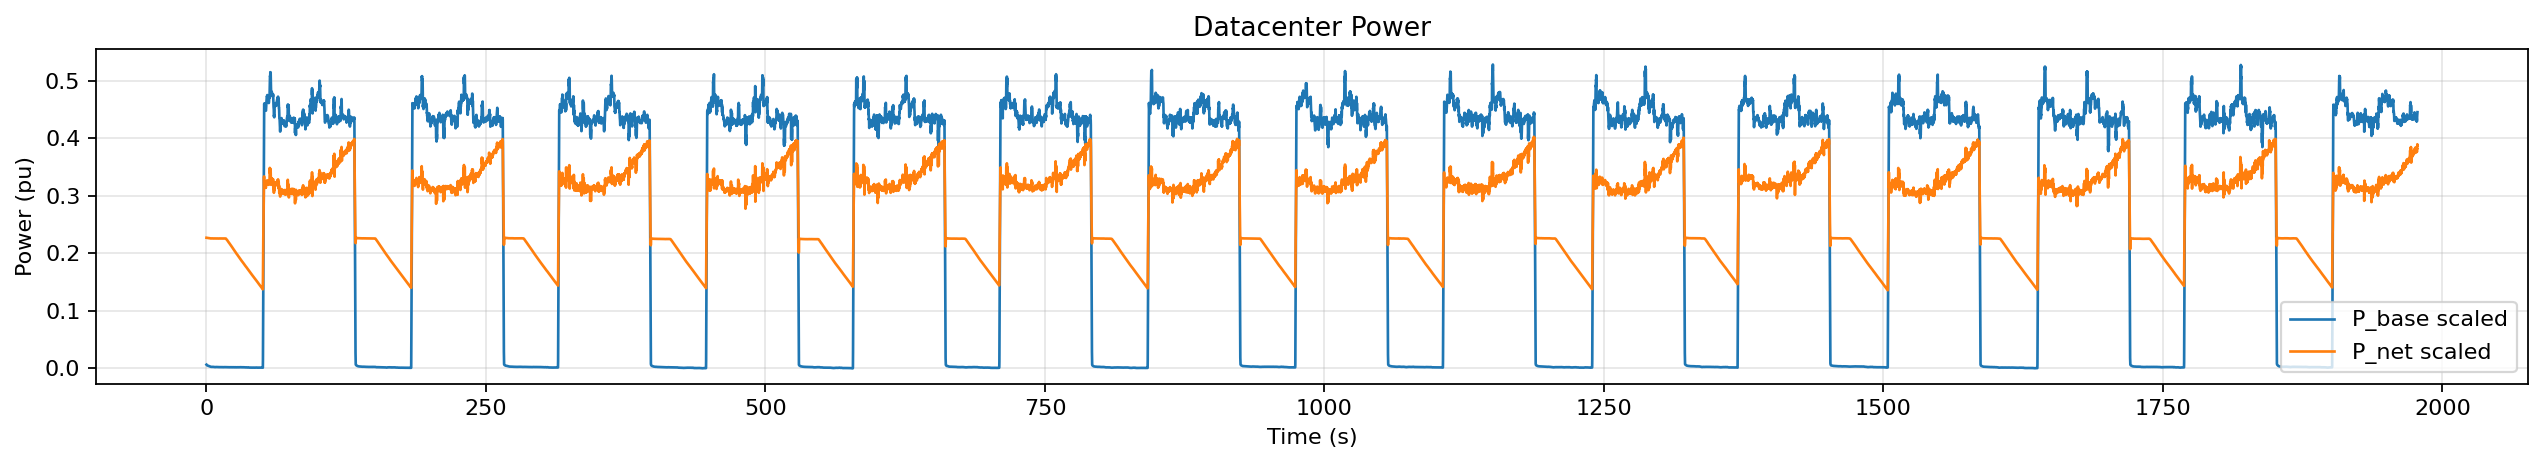

In [ ]:
# ---- P_base ----
dP_base_scale, scale_base = rescale_diff(P_base, amp, return_scale=True)

xmin_base, xmax_base = np.min(P_base), np.max(P_base)
range_base = xmax_base - xmin_base
p0_base = pwr_sys_scale[-1]
P_base_scale = np.concatenate([[p0_base], p0_base + np.cumsum(dP_base_scale)])

# ---- P_net: keep original amplitude ratio relative to P_base ----
xmin_net, xmax_net = np.min(P_net), np.max(P_net)
range_net = xmax_net - xmin_net
amp_net = amp * range_net / range_base
dP_net_scale = rescale_diff(P_net, amp_net, return_scale=False)

# choose the starting level as you like
# p0_net = p0_base
p0_net = (P_net[0] - xmin_base) / (xmax_base - xmin_base) * amp + p0_base
P_net_scale = np.concatenate([[p0_net], p0_net + np.cumsum(dP_net_scale)])

# plot
plt.figure(figsize=(16, 3), dpi=160)
plt.plot(ts[:len(P_base_scale)], P_base_scale, lw=1.2, label="P_base scaled")
plt.plot(ts[:len(P_net_scale)], P_net_scale, lw=1.2, label="P_net scaled")

plt.xlabel("Time (s)")
plt.ylabel("Power (pu)")
plt.title("Datacenter Power")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### merge

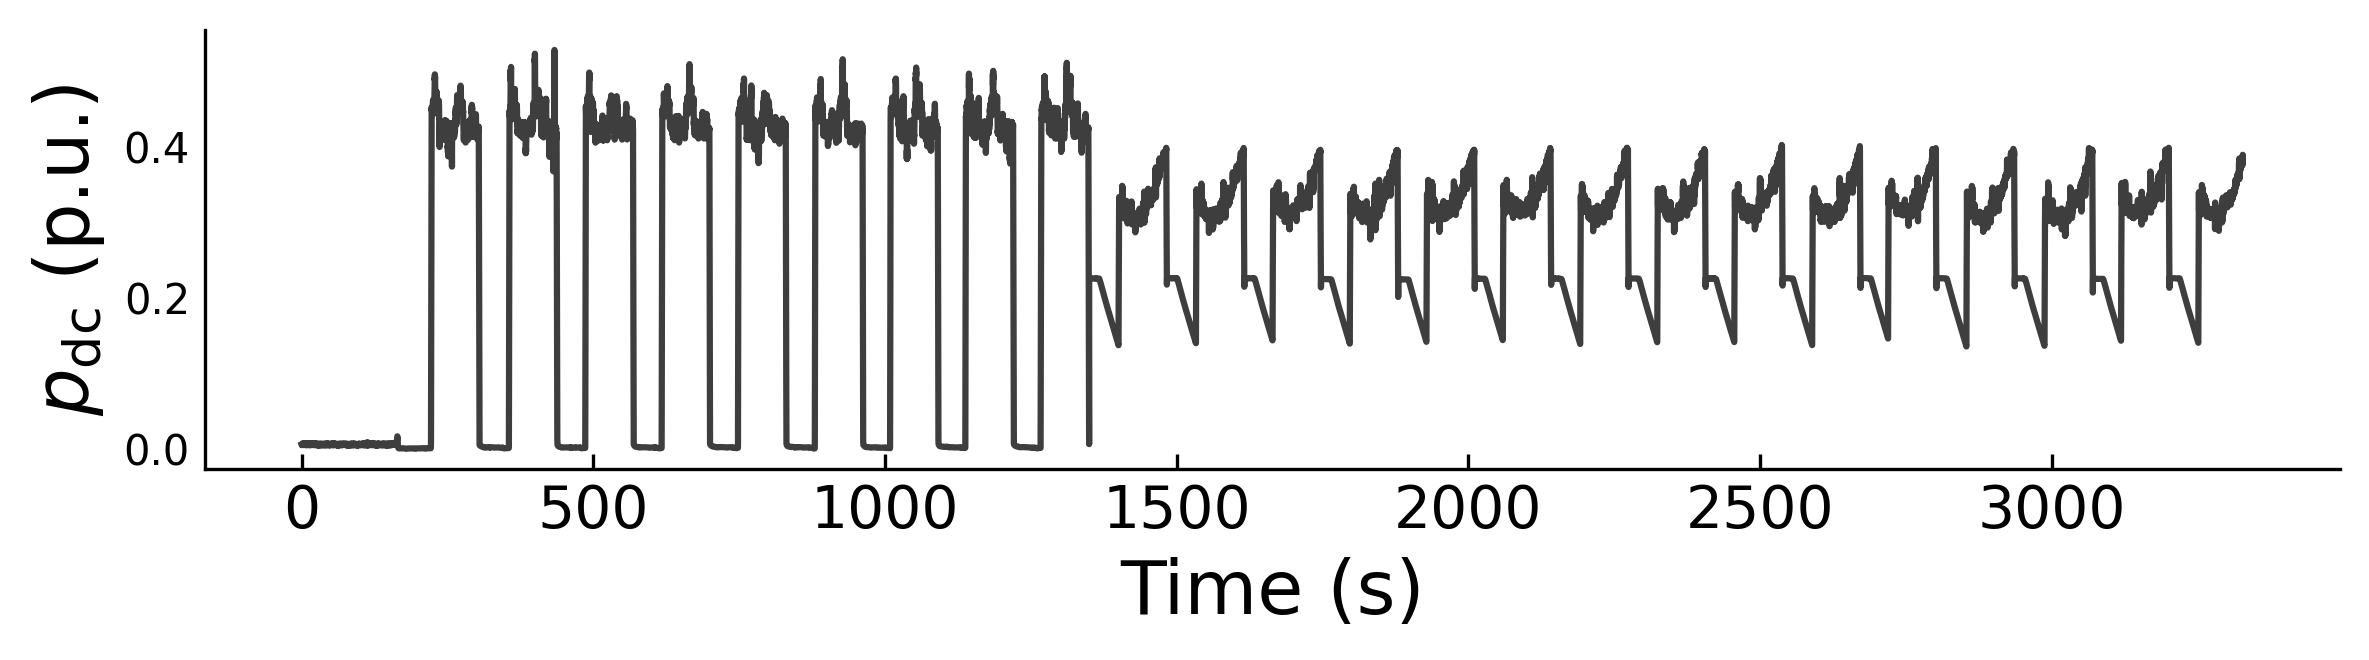

In [ ]:
P_combined = np.concatenate([pwr_sys_scale, P_net_scale[1:]])
t_combined = np.arange(len(P_combined)) * 0.1

P_COLOR = "0.2"

fig, ax = plt.subplots(figsize=(8.0, 2.3), dpi=300)

ax.plot(t_combined, P_combined, color=P_COLOR, lw=1.5, alpha=0.95)

ax.set_xlabel("Time (s)", fontsize=18)
ax.set_ylabel(r"$p_{\mathrm{dc}}$ (p.u.)", fontsize=18)
# ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ymin = float(P_combined.min())
ymax = float(P_combined.max())
yr = ymax - ymin
ax.set_ylim(ymin - 0.05 * yr, ymax + 0.05 * yr)

ax.tick_params(axis="x", labelsize=14, direction="in")
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

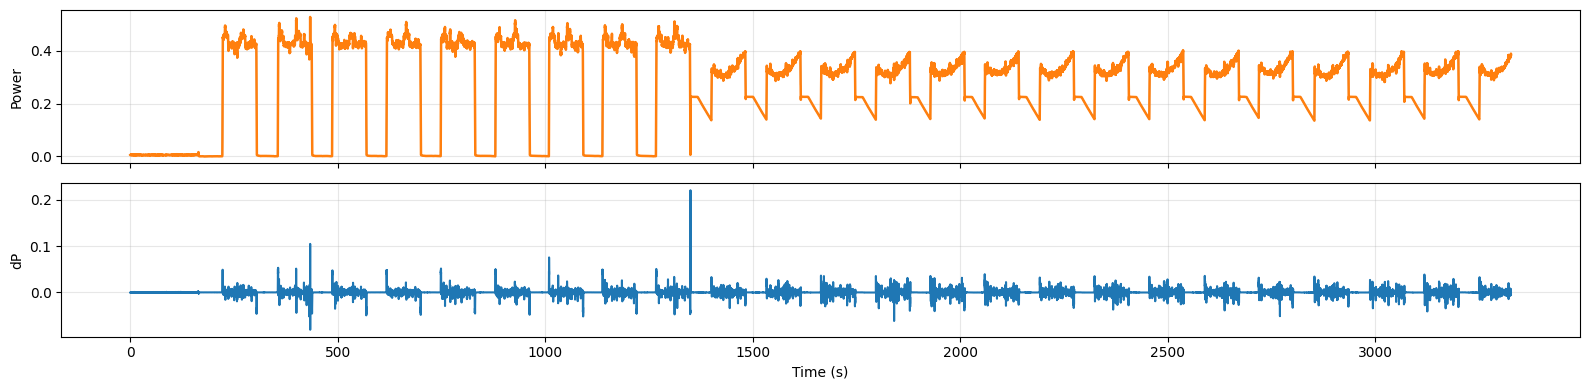

In [ ]:
# select a time window
slice_range = slice(None, None)
t_raw  = t_combined[slice_range]
pwr_raw = P_combined[slice_range]

# system grid
# t_sys = np.arange(t_raw[0], t_raw[-1] + 1e-9, dt_sys, dtype=np.float64)
# pwr_sys = np.interp(t_sys, t_raw, pwr_raw).astype(np.float32)
t_sys = t_raw
pwr_sys = pwr_raw

# pwr grid: subsampled from system grid
t_pwr = t_sys[::stride_pwr]
pwr_pwr = -pwr_sys[::stride_pwr]

# system disturbance
dP_sys, scale = rescale_diff(pwr_sys, amp, return_scale=True)
dP_last, T_sys = make_dP_last_from_data(dP_sys)
v_sens = scale * R_dc_row  # (n,)
SimulationLength = T_sys

# visualize (system grid)
plot_power_preprocessing(t_raw, pwr_raw, t_sys, pwr_sys, dP_sys, dt_sys)

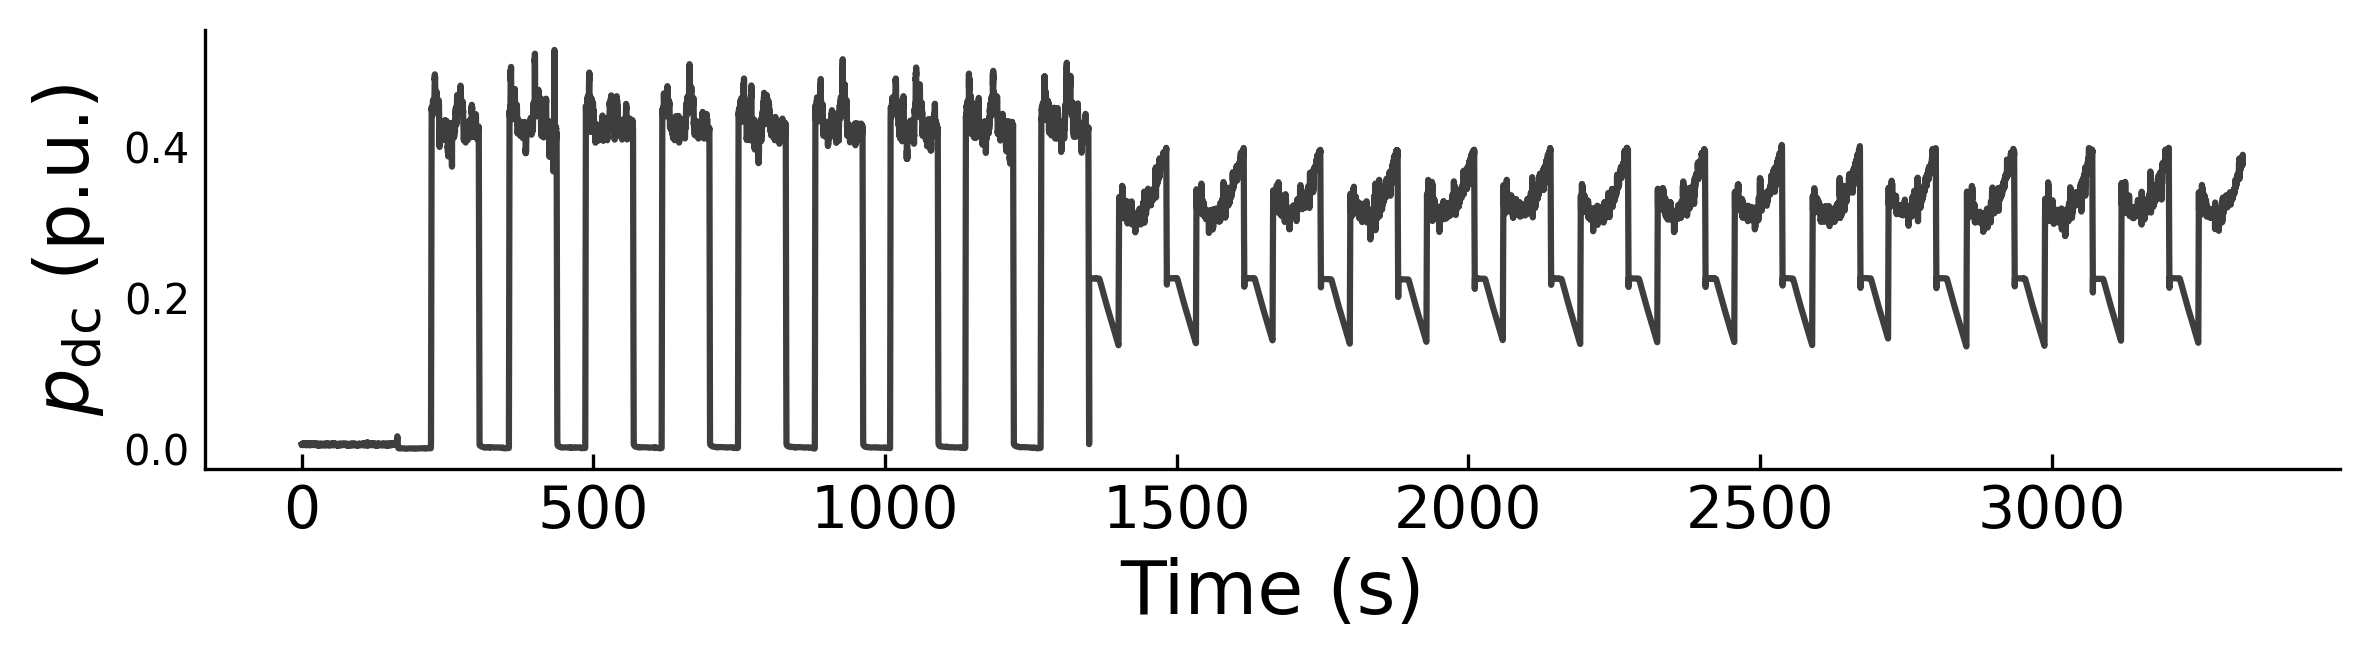

In [ ]:
# P_combined = np.concatenate([pwr_sys_scale, P_base_scale[1:]])
# P_combined = np.concatenate([pwr_sys_scale, P_net_scale[1:]])
P_sys = np.concatenate([[P_combined[0]], P_combined[0] + np.cumsum(dP_sys)])
t_combined = np.arange(len(P_sys)) * 0.1

P_COLOR = "0.2"

fig, ax = plt.subplots(figsize=(8.0, 2.3), dpi=300)

ax.plot(t_combined, P_sys, color=P_COLOR, lw=1.5, alpha=0.95)

ax.set_xlabel("Time (s)", fontsize=18)
ax.set_ylabel(r"$p_{\mathrm{dc}}$ (p.u.)", fontsize=18)
# ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ymin = float(P_sys.min())
ymax = float(P_sys.max())
yr = ymax - ymin
ax.set_ylim(ymin - 0.05 * yr, ymax + 0.05 * yr)

ax.tick_params(axis="x", labelsize=14, direction="in")
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

### zero-ref

#### w/o deadband

[Seed set]: 42


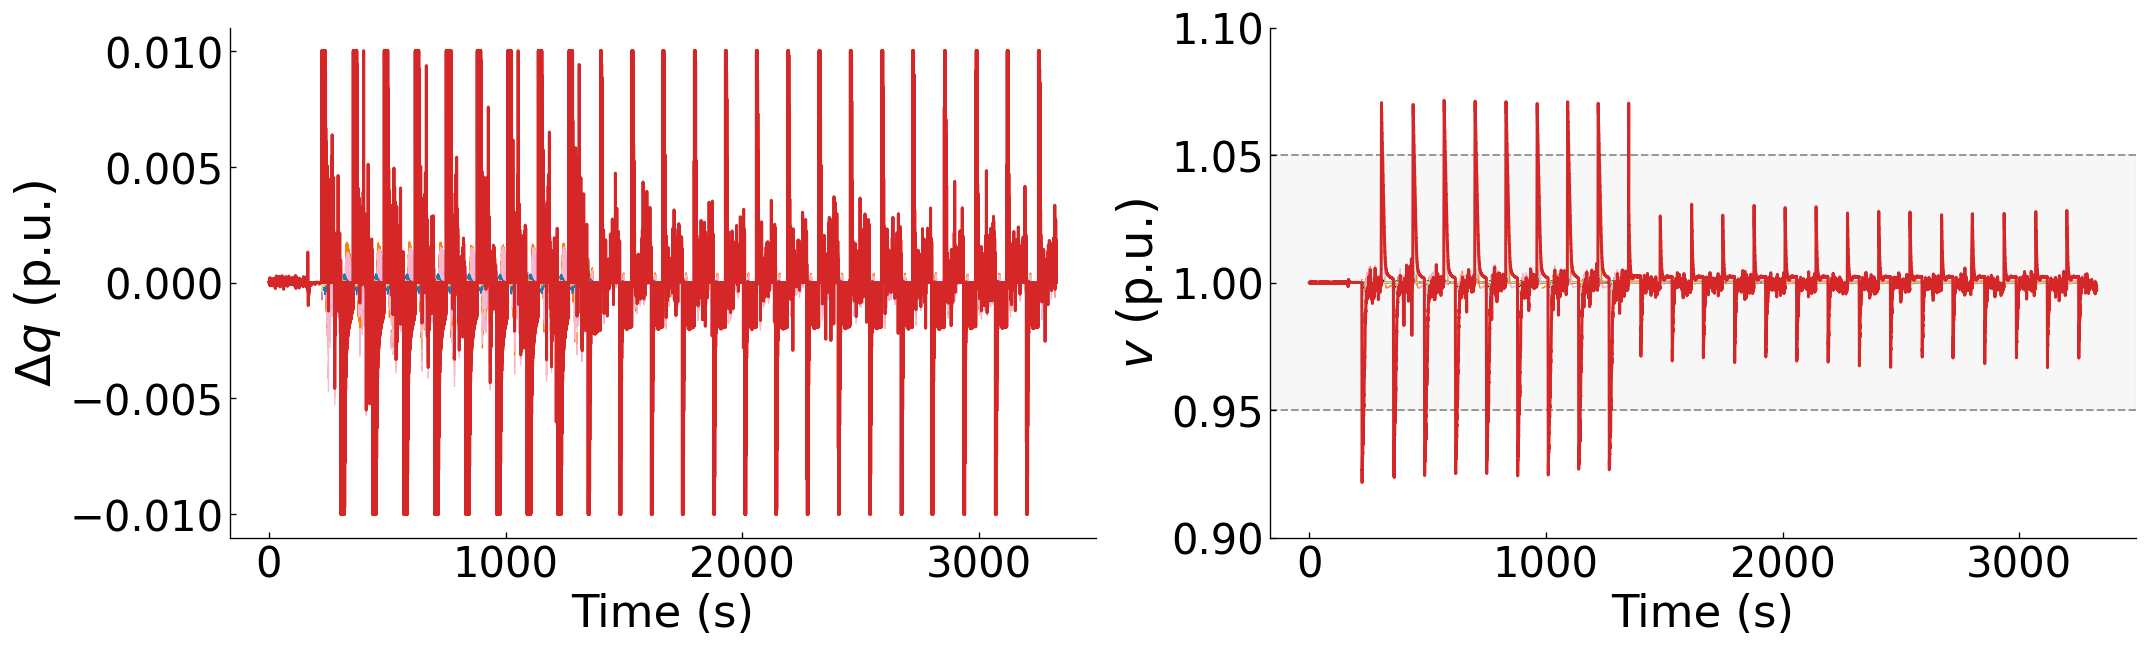

In [ ]:
# --- user-defined configuration ---
stride_ctrl = 10
gain_scale = 50
deadband = 0.0

# --- derived parameters and main simulation loop --
set_seed(SEED)
dt_ctrl = stride_ctrl * dt_sys
V = env.reset(P=P0_INIT, balance_Q=True)

# --- logging buffers ---
record_dQ = []
record_V = [V.squeeze().copy()]

for k_sys in range(SimulationLength):
    dP_t = np.zeros_like(P0)
    dP_t[dc_bus, 0] = dP_last(k_sys)

    dQ = np.zeros((num_buses, 1), dtype=np.float32)  # impulse control: only nonzero at ctrl steps
    if k_sys % stride_ctrl == 0:
        V_ref = np.zeros((num_buses, 1), dtype=np.float32)
        dQ = action_linear(V, linear_coff * gain_scale, V_ref, deadband=deadband).reshape(num_buses, 1).astype(np.float32)

    V = env.step(dQ, dP=dP_t)

    record_dQ.append(dQ.squeeze().copy())
    record_V.append(V.squeeze().copy())

# visualizatoin
record_dQ, record_V = plot_dQ_and_V(record_dQ, record_V, dt=env.dt, dc_buses=[dc_bus])

#### deadband=0.02

[Seed set]: 42


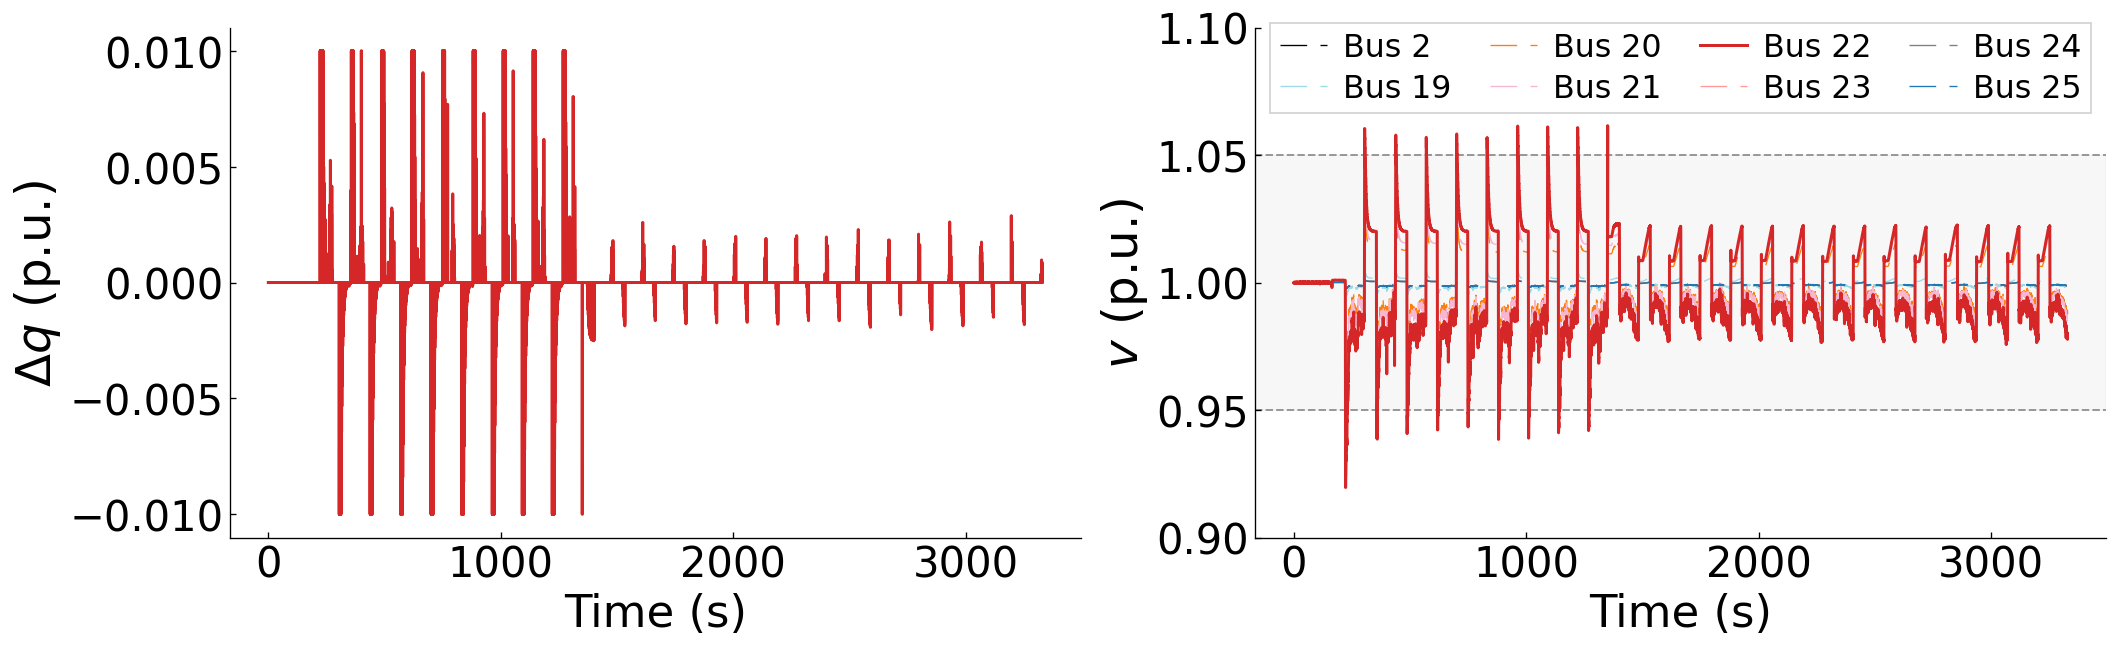

In [ ]:
# --- user-defined configuration ---
stride_ctrl = 10
gain_scale = 50
deadband = 0.02

# --- derived parameters and main simulation loop --
set_seed(SEED)
dt_ctrl = stride_ctrl * dt_sys
V = env.reset(P=P0_INIT, balance_Q=True)

# --- logging buffers ---
record_dQ = []
record_V = [V.squeeze().copy()]

for k_sys in range(SimulationLength):
    dP_t = np.zeros_like(P0)
    dP_t[dc_bus, 0] = dP_last(k_sys)

    dQ = np.zeros((num_buses, 1), dtype=np.float32)  # impulse control: only nonzero at ctrl steps
    if k_sys % stride_ctrl == 0:
        V_ref = np.zeros((num_buses, 1), dtype=np.float32)
        dQ = action_linear(V, linear_coff * gain_scale, V_ref, deadband=deadband).reshape(num_buses, 1).astype(np.float32)

    V = env.step(dQ, dP=dP_t)

    record_dQ.append(dQ.squeeze().copy())
    record_V.append(V.squeeze().copy())

# visualizatoin
record_dQ, record_V = plot_dQ_and_V(record_dQ, record_V, dt=env.dt, dc_buses=[dc_bus], plot_buses=plot_buses, show_legend=True)

In [ ]:
results = {}
results["zero_ref"] = {
    "dQ": record_dQ[:, dc_bus],
    "V": record_V[:, dc_bus],
}

### ada-ref

#### w/o deadband

[Seed set]: 42


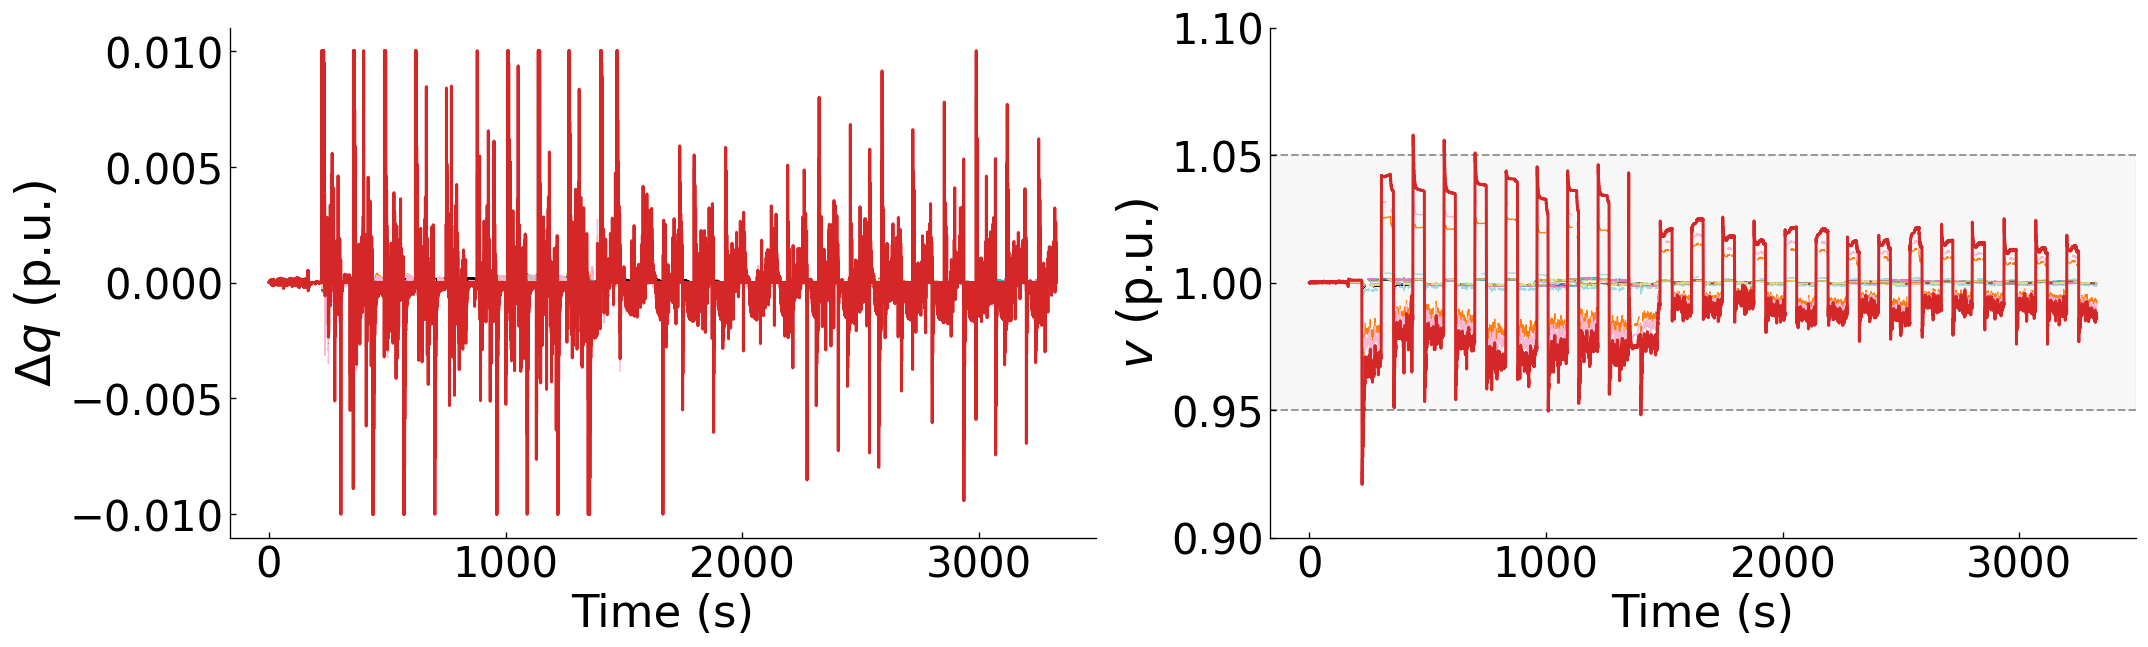

In [ ]:
# --- user-defined configuration ---
stride_ctrl = 10
gain_scale = 50
action_kwargs = {"deadband": 0.0}
bias_win_secs, bias_per_secs, bias_skip_secs, bias_frac = 120, 10, 0, 0.020
amp_win_secs = 120

# --- derived parameters and main simulation loop ---
set_seed(SEED)
dt_ctrl = stride_ctrl * dt_sys

bias_len  = max(0, int(round(bias_win_secs  / dt_ctrl)))
bias_per = int(round(bias_per_secs / dt_ctrl))
bias_skip = int(round(bias_skip_secs / dt_ctrl))

amp_win_len  = max(1, int(round(amp_win_secs / dt_ctrl)))
dv_hist_len = max(amp_win_len, 5000)   # make sure >= amp_win_len

V = env.reset(P=P0_INIT, balance_Q=True)
controller = AdaRefVBiasAmpMaxDV(
    n=num_buses,
    K=linear_coff * gain_scale, action_kwargs=action_kwargs,
    bias_len=bias_len, bias_per=bias_per, bias_skip=bias_skip, bias_frac=bias_frac,
    dv_hist_len=dv_hist_len, dv_beta=None,
    cooldown_steps=0,
    amp_gain=0.5, amp_win_len=amp_win_len, amp_per=1, amp_min=None,
)

# --- logging buffers ---
record_dQ = []
record_Vref = []
record_V = [V.squeeze().copy()]

for k_sys in range(SimulationLength):
    # Real power fluctuation at data center bus
    dP_t = np.zeros_like(P0)
    dP_t[dc_bus, 0] = dP_last(k_sys)

    # Reactive power control update only at control stride
    dQ = np.zeros((num_buses, 1), dtype=np.float32)
    if k_sys % stride_ctrl == 0:
        dQ = controller.step(V).reshape(num_buses, 1).astype(np.float32)

    # Propagate system dynamics
    V = env.step(dQ, dP=dP_t)

    # logging
    record_dQ.append(dQ.squeeze().copy())
    record_Vref.append(controller.V_ref.squeeze().copy())
    record_V.append(V.squeeze().copy())

# visualization
# record_dQ, record_V, record_Vref = plot_dQ_and_V(record_dQ, record_V, record_Vref, dt=env.dt)
record_dQ, record_V = plot_dQ_and_V(record_dQ, record_V, dt=env.dt, dc_buses=[dc_bus])

#### deadband=0.02

[Seed set]: 42


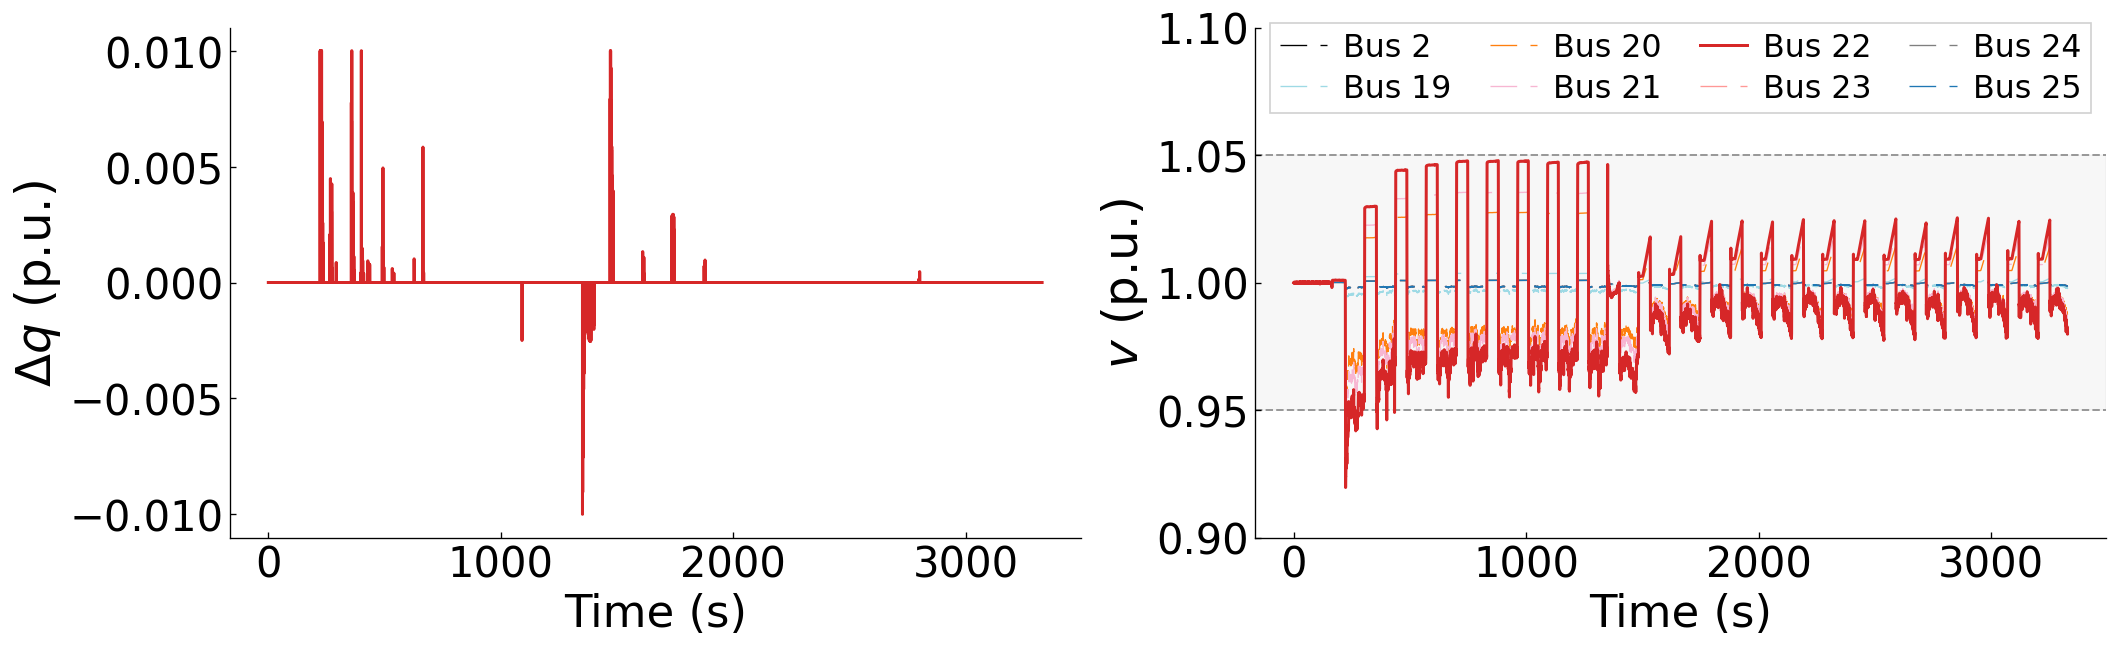

In [ ]:
# --- user-defined configuration ---
stride_ctrl = 10
# gain_scale = 15
gain_scale = 50
action_kwargs = {"deadband": 0.02}
bias_win_secs, bias_per_secs, bias_skip_secs, bias_frac = 120, 10, 0, 0.020
amp_win_secs = 120

# --- derived parameters and main simulation loop ---
set_seed(SEED)
dt_ctrl = stride_ctrl * dt_sys

bias_len  = max(0, int(round(bias_win_secs  / dt_ctrl)))
bias_per = int(round(bias_per_secs / dt_ctrl))
bias_skip = int(round(bias_skip_secs / dt_ctrl))

amp_win_len  = max(1, int(round(amp_win_secs / dt_ctrl)))
dv_hist_len = max(amp_win_len, 5000)   # make sure >= amp_win_len

V = env.reset(P=P0_INIT, balance_Q=True)
controller = AdaRefVBiasAmpMaxDV(
    n=num_buses,
    K=linear_coff * gain_scale, action_kwargs=action_kwargs,
    bias_len=bias_len, bias_per=bias_per, bias_skip=bias_skip, bias_frac=bias_frac,
    dv_hist_len=dv_hist_len, dv_beta=None,
    cooldown_steps=0,
    amp_gain=0.5, amp_win_len=amp_win_len, amp_per=1, amp_min=None,
)

# --- logging buffers ---
record_dQ = []
record_Vref = []
record_V = [V.squeeze().copy()]

for k_sys in range(SimulationLength):
    # Real power fluctuation at data center bus
    dP_t = np.zeros_like(P0)
    dP_t[dc_bus, 0] = dP_last(k_sys)

    # Reactive power control update only at control stride
    dQ = np.zeros((num_buses, 1), dtype=np.float32)
    if k_sys % stride_ctrl == 0:
        dQ = controller.step(V).reshape(num_buses, 1).astype(np.float32)

    # Propagate system dynamics
    V = env.step(dQ, dP=dP_t)

    # logging
    record_dQ.append(dQ.squeeze().copy())
    record_Vref.append(controller.V_ref.squeeze().copy())
    record_V.append(V.squeeze().copy())

# visualization
record_dQ, record_V = plot_dQ_and_V(record_dQ, record_V, dt=env.dt, dc_buses=[dc_bus], plot_buses=plot_buses, show_legend=True)

In [ ]:
results["ada_ref"] = {
    "dQ": record_dQ[:, dc_bus],
    "V": record_V[:, dc_bus],
}

### comparison

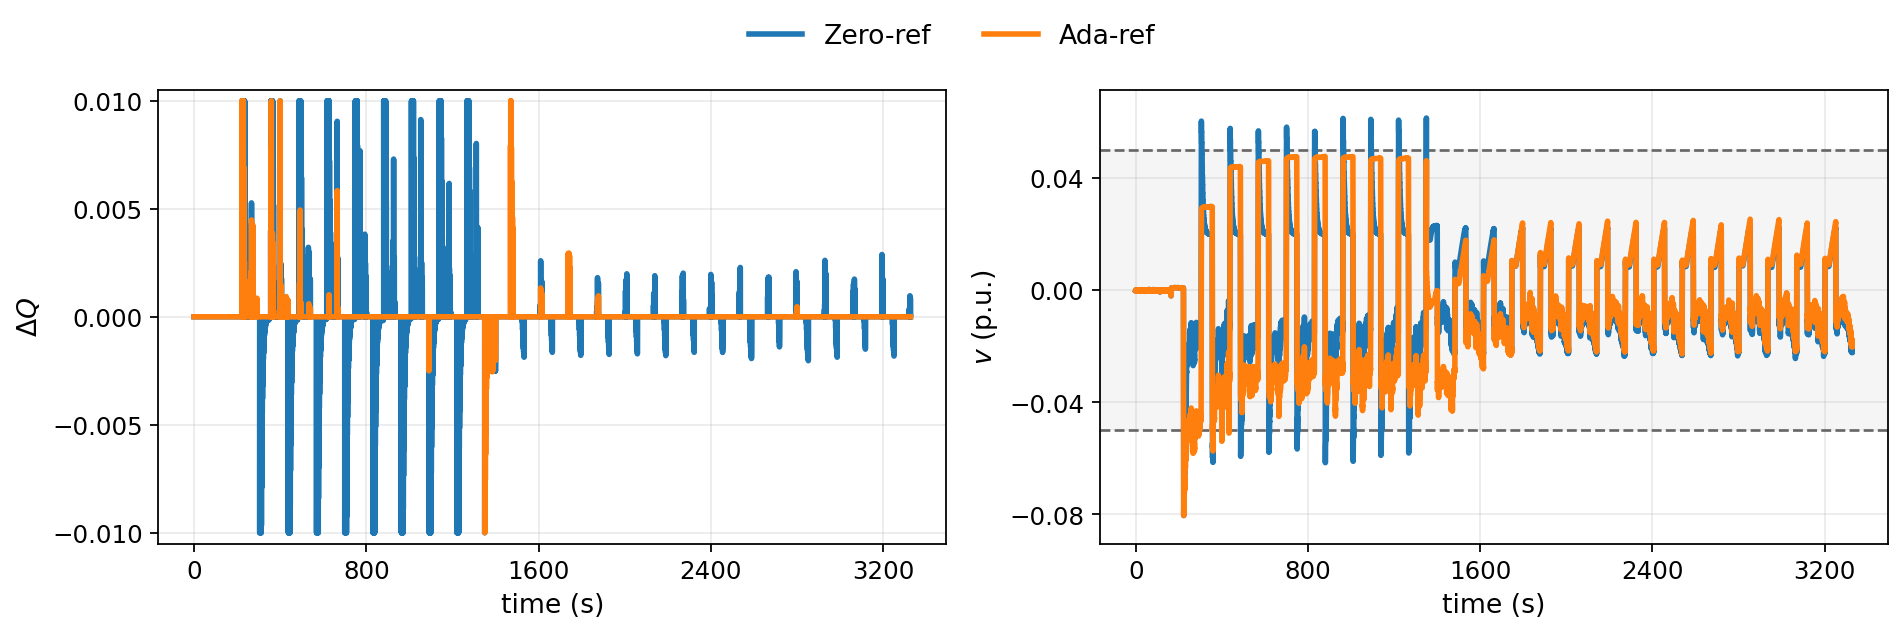

In [ ]:
def plot_dc_compare(results, dt=0.1, vmin=-0.05, vmax=0.05,
                    names=("zero_ref", "ada_ref"),
                    labels=("Zero-ref", "Ada-ref")):

    z, a = names
    dq0, v0 = np.asarray(results[z]["dQ"]), np.asarray(results[z]["V"])
    dq1, v1 = np.asarray(results[a]["dQ"]), np.asarray(results[a]["V"])

    t_q0, t_v0 = dt*np.arange(1, len(dq0)+1), dt*np.arange(len(v0))
    t_q1, t_v1 = dt*np.arange(1, len(dq1)+1), dt*np.arange(len(v1))

    c0, c1 = plt.get_cmap("tab10")(0), plt.get_cmap("tab10")(1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=160)

    # --- ΔQ ---
    ax[0].plot(t_q0, dq0, color=c0, lw=2.5, label=labels[0])
    ax[0].plot(t_q1, dq1, color=c1, lw=2.5, label=labels[1])
    # ax[0].set_title(r"$\Delta Q$", fontsize=14)
    ax[0].set_xlabel("time (s)", fontsize=12)
    ax[0].set_ylabel(r"$\Delta Q$", fontsize=12)
    ax[0].grid(True, alpha=0.25)

    # Fewer ticks
    ax[0].xaxis.set_major_locator(MaxNLocator(6))
    ax[0].yaxis.set_major_locator(MaxNLocator(5))

    lim = max(np.max(np.abs(dq0)), np.max(np.abs(dq1)), 1e-6)
    ax[0].set_ylim(-1.05*lim, 1.05*lim)

    # --- V ---
    ax[1].axhspan(vmin, vmax, color="0.85", alpha=0.25, zorder=0)
    ax[1].axhline(vmax, color="0.4", ls="--", lw=1.2)
    ax[1].axhline(vmin, color="0.4", ls="--", lw=1.2)

    ax[1].plot(t_v0, v0, color=c0, lw=2.5)
    ax[1].plot(t_v1, v1, color=c1, lw=2.5)

    # ax[1].set_title("Voltage (p.u.)", fontsize=14)
    ax[1].set_xlabel("time (s)", fontsize=12)
    ax[1].set_ylabel(r"$v$ (p.u.)", fontsize=12)
    ax[1].grid(True, alpha=0.25)

    ax[1].xaxis.set_major_locator(MaxNLocator(6))
    ax[1].yaxis.set_major_locator(MaxNLocator(5))

    ylo = min(v0.min(), v1.min(), vmin) - 0.01
    yhi = max(v0.max(), v1.max(), vmax) + 0.01
    ax[1].set_ylim(ylo, yhi)

    # Larger tick labels
    for axt in ax:
        axt.tick_params(labelsize=11)

    # Top legend
    handles, labs = ax[0].get_legend_handles_labels()
    fig.legend(handles, labs, loc="upper center", ncol=2,
               frameon=False, fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

plot_dc_compare(results, dt=0.1, vmin=-0.05, vmax=0.05)

## 2bus_torch_ckpt_end

In [ ]:
# dc_buses = [17, 20]
dc_buses = [20, 23]
dc_configs = {}
for dc_bus in dc_buses:
    dc_configs[dc_bus] = {
        "amp": 0.10 * 0.95 / R[dc_bus, dc_bus]
    }

dc_configs

{20: {'amp': np.float32(0.52890724)}, 23: {'amp': np.float32(0.5379516)}}

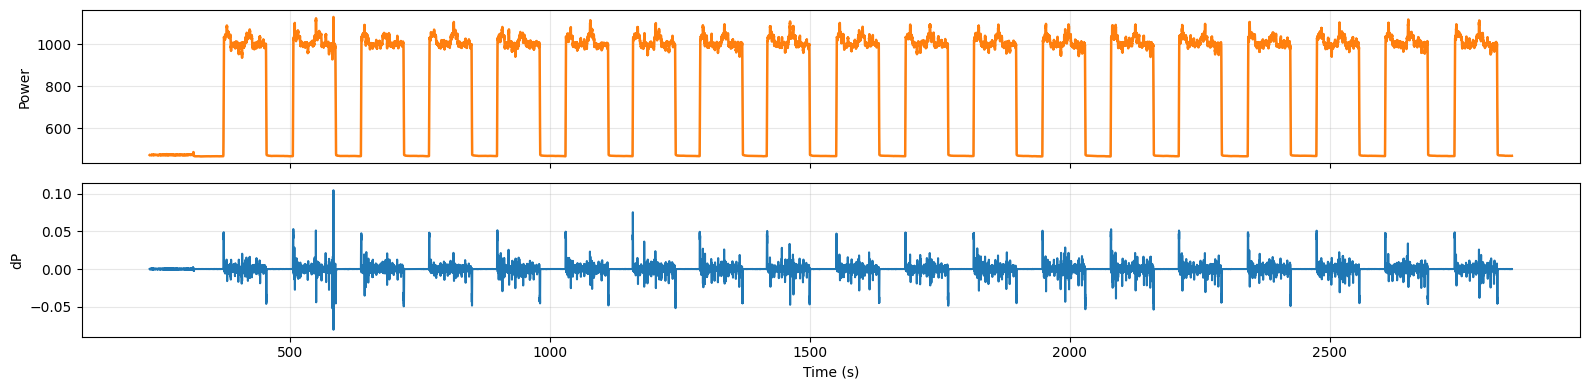

In [ ]:
dc_bus = dc_buses[0]
config = dc_configs[dc_bus]

# data loading
data_dir = osp.join("..", "data", "traces_raw")
filename = "L2-70B-chat_4xH200_HF_qlora_tp_async_b16x2_seq2048_r64_ckpt1.csv"
df = pd.read_csv(osp.join(data_dir, filename))

# select a time window
slice_range = slice(2300, 28500)
t_raw  = df["t"][slice_range].to_numpy(np.float64)
pwr_raw = df["pwr"][slice_range].to_numpy(np.float32)

# system grid
t_sys = np.arange(t_raw[0], t_raw[-1] + 1e-9, dt_sys, dtype=np.float64)
pwr_sys = np.interp(t_sys, t_raw, pwr_raw).astype(np.float32)

# pwr grid: subsampled from system grid
t_pwr = t_sys[::stride_pwr]
pwr_pwr = -pwr_sys[::stride_pwr]

# system disturbance
dP_sys, scale = rescale_diff(pwr_sys, config["amp"], return_scale=True)
dP_last_0, T_sys = make_dP_last_from_data(dP_sys)
v_sens = scale * R_dc_row  # (n,)
SimulationLength = T_sys

# visualize (system grid)
plot_power_preprocessing(t_raw, pwr_raw, t_sys, pwr_sys, dP_sys, dt_sys)

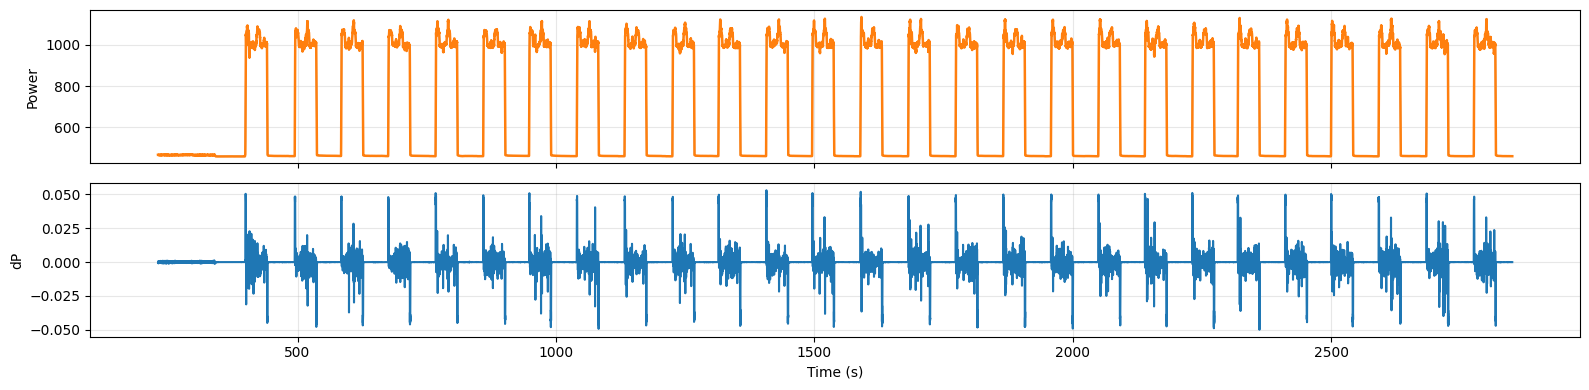

In [ ]:
dc_bus = dc_buses[1]
config = dc_configs[dc_bus]

# data loading
data_dir = osp.join("..", "data", "traces_raw")
filename = "L2-70B-chat_4xH200_HF_qlora_tp_async_b8x2_seq2048_r64_ckpt1.csv"
df = pd.read_csv(osp.join(data_dir, filename))

# select a time window
slice_range = slice(2300, 28500)
t_raw  = df["t"][slice_range].to_numpy(np.float64)
pwr_raw = df["pwr"][slice_range].to_numpy(np.float32)

# system grid
t_sys = np.arange(t_raw[0], t_raw[-1] + 1e-9, dt_sys, dtype=np.float64)
pwr_sys = np.interp(t_sys, t_raw, pwr_raw).astype(np.float32)

# pwr grid: subsampled from system grid
t_pwr = t_sys[::stride_pwr]
pwr_pwr = -pwr_sys[::stride_pwr]

# system disturbance
dP_sys, scale = rescale_diff(pwr_sys, config["amp"], return_scale=True)
dP_last_1, T_sys = make_dP_last_from_data(dP_sys)
v_sens = scale * R_dc_row  # (n,)
SimulationLength = T_sys

# visualize (system grid)
plot_power_preprocessing(t_raw, pwr_raw, t_sys, pwr_sys, dP_sys, dt_sys)

### zero-ref

[Seed set]: 42


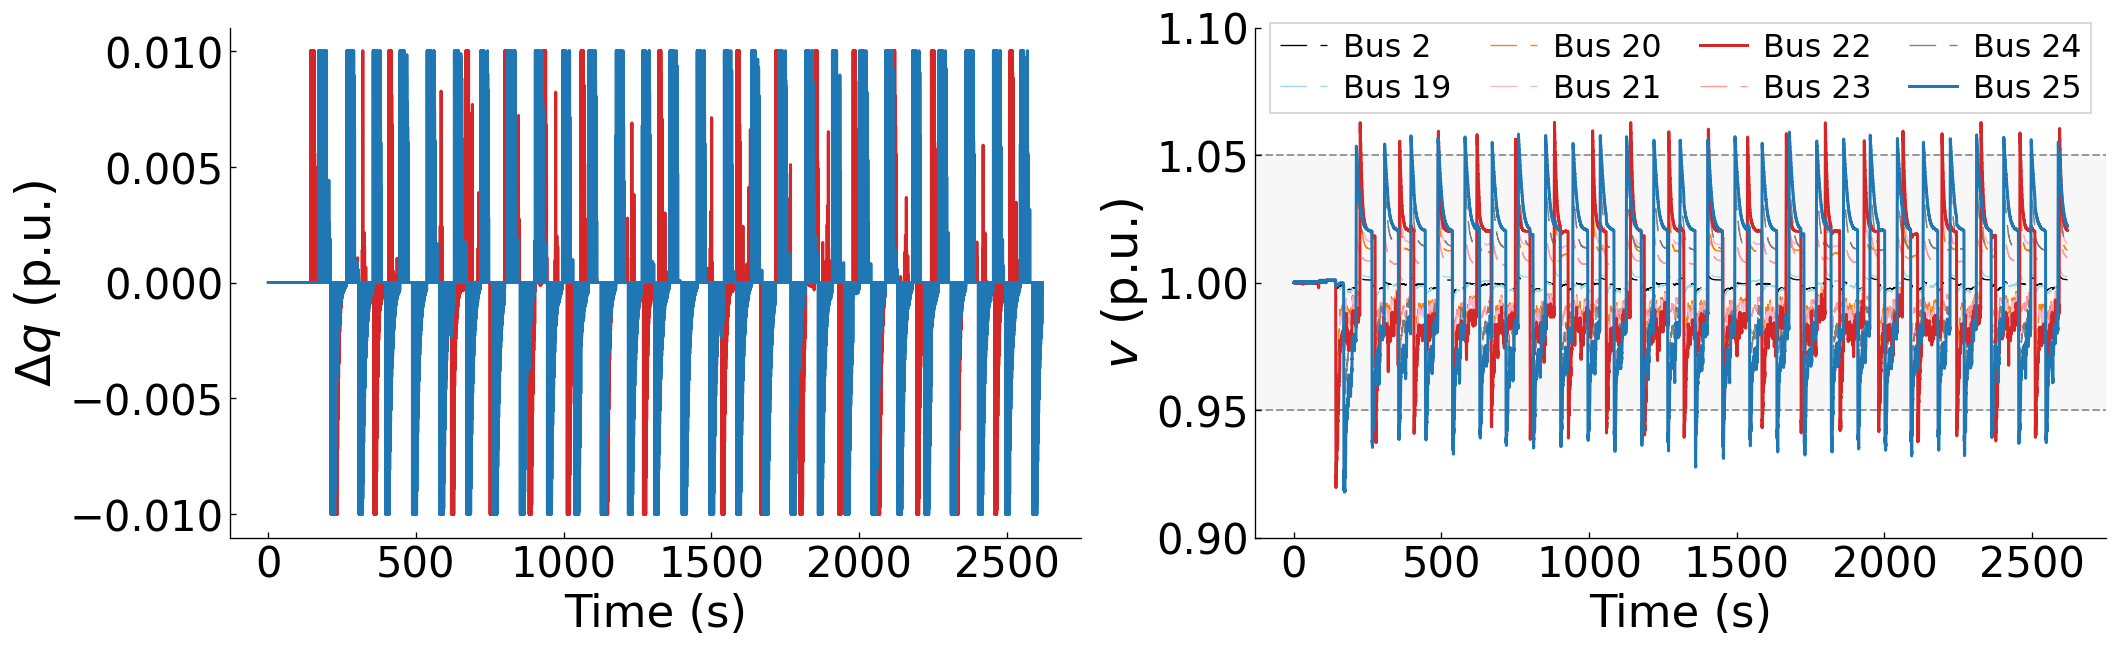

In [ ]:
# --- user-defined configuration ---
stride_ctrl = 10
gain_scale = 50
deadband = 0.02

# --- derived parameters and main simulation loop --
set_seed(SEED)
dt_ctrl = stride_ctrl * dt_sys
V = env.reset(P=P0_INIT, balance_Q=True)

# --- logging buffers ---
record_dQ = []
record_V = [V.squeeze().copy()]

for k_sys in range(SimulationLength):
    dP_t = np.zeros_like(P0)
    dP_t[dc_buses[0], 0] = dP_last_0(k_sys)
    dP_t[dc_buses[1], 0] = dP_last_1(k_sys)

    dQ = np.zeros((num_buses, 1), dtype=np.float32)  # impulse control: only nonzero at ctrl steps
    if k_sys % stride_ctrl == 0:
        V_ref = np.zeros((num_buses, 1), dtype=np.float32)
        dQ = action_linear(V, linear_coff * gain_scale, V_ref, deadband=deadband).reshape(num_buses, 1).astype(np.float32)

    V = env.step(dQ, dP=dP_t)

    record_dQ.append(dQ.squeeze().copy())
    record_V.append(V.squeeze().copy())

# visualizatoin
record_dQ, record_V = plot_dQ_and_V(record_dQ, record_V, dt=env.dt, plot_buses=plot_buses, show_legend=True)

### ada-ref

[Seed set]: 42


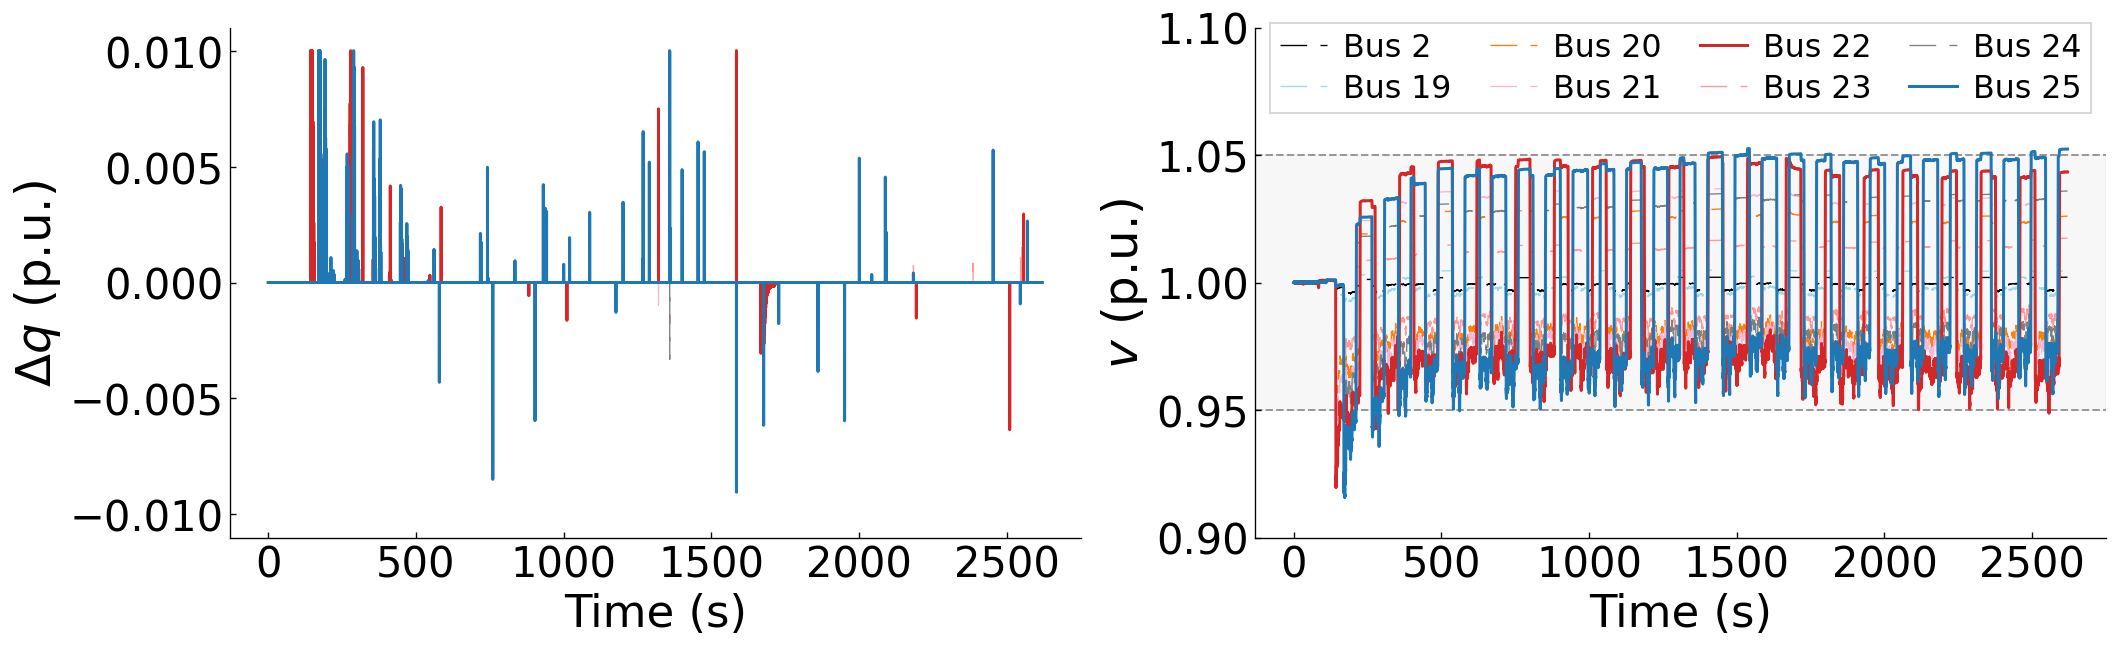

In [ ]:
# --- user-defined configuration ---
stride_ctrl = 10
gain_scale = 50
action_kwargs = {"deadband": 0.02}
bias_win_secs, bias_per_secs, bias_skip_secs, bias_frac = 120, 10, 0, 0.02
amp_win_secs = 120

# --- derived parameters and main simulation loop ---
set_seed(SEED)
dt_ctrl = stride_ctrl * dt_sys

bias_len  = max(0, int(round(bias_win_secs  / dt_ctrl)))
bias_per = int(round(bias_per_secs / dt_ctrl))
bias_skip = int(round(bias_skip_secs / dt_ctrl))

amp_win_len  = max(1, int(round(amp_win_secs / dt_ctrl)))
dv_hist_len = max(amp_win_len, 5000)   # make sure >= amp_win_len

V = env.reset(P=P0_INIT, balance_Q=True)
controller = AdaRefVBiasAmpMaxDV(
    n=num_buses,
    K=linear_coff * gain_scale, action_kwargs=action_kwargs,
    bias_len=bias_len, bias_per=bias_per, bias_skip=bias_skip, bias_frac=bias_frac,
    dv_hist_len=dv_hist_len, dv_beta=None,
    cooldown_steps=0,
    amp_gain=0.5, amp_win_len=amp_win_len, amp_per=1, amp_min=None,
)

# --- logging buffers ---
record_dQ = []
record_Vref = []
record_V = [V.squeeze().copy()]

for k_sys in range(SimulationLength):
    # Real power fluctuation at data center bus
    dP_t = np.zeros_like(P0)
    dP_t[dc_buses[0], 0] = dP_last_0(k_sys)
    dP_t[dc_buses[1], 0] = dP_last_1(k_sys)

    # Reactive power control update only at control stride
    dQ = np.zeros((num_buses, 1), dtype=np.float32)
    if k_sys % stride_ctrl == 0:
        dQ = controller.step(V).reshape(num_buses, 1).astype(np.float32)

    # Propagate system dynamics
    V = env.step(dQ, dP=dP_t)

    # logging
    record_dQ.append(dQ.squeeze().copy())
    record_Vref.append(controller.V_ref.squeeze().copy())
    record_V.append(V.squeeze().copy())

# visualization
record_dQ, record_V = plot_dQ_and_V(record_dQ, record_V, dt=env.dt, plot_buses=plot_buses, show_legend=True)